# 🔬 VQA-E: Visual Question Answering with Explanation — Local Training

## Dự án: Xây dựng hệ thống VQA sinh câu trả lời kèm giải thích

**Mục tiêu**: Cho 1 ảnh + 1 câu hỏi → sinh ra `"answer because explanation"` bằng LSTM Decoder  
**Dataset**: VQA-E (Li et al., 2018) — dựa trên COCO 2014  
**Máy local**: CPU Intel i7-14700K | RAM 64GB | GPU RTX 3060 12GB VRAM

### 4 Model variants so sánh:
| Model | CNN | Attention | Pretrained | Mô tả |
|-------|-----|-----------|------------|--------|
| **A** | SimpleCNN (5 conv blocks) | ❌ | ❌ | Baseline đơn giản nhất |
| **B** | ResNet101 (frozen→unfreeze) | ❌ | ✅ ImageNet | Pretrained CNN, no attention |
| **C** | SimpleCNN Spatial (49 regions) | ✅ Dual Attention | ❌ | Scratch CNN + Attention + Coverage |
| **D** | ResNet101 Spatial (49 regions) | ✅ Dual Attention | ✅ ImageNet | Full model (best expected) |

### 11 Cải tiến kiến trúc đã tích hợp:
| # | Cải tiến | Mô tả |
|---|----------|--------|
| 1 | **Label Smoothing** | `CrossEntropyLoss(label_smoothing=0.1)` — giảm overconfident |
| 2 | **BiLSTM Encoder** | Bidirectional LSTM cho question — bắt context 2 chiều |
| 3 | **Gated Fusion** | `gate * tanh(W_img) + (1-gate) * tanh(W_q)` thay Hadamard |
| 4 | **Dual Attention** | Attend cả image regions VÀ question tokens (Model C/D) |
| 5 | **LR Warmup** | 3 epochs warmup (lr/10 → lr) trước CosineAnnealing |
| 6 | **GloVe 300d** | Pretrained word embeddings + projection 300d → 512d |
| 7 | **No Weight Tying** | Separate output embeddings khi dùng GloVe (tránh bottleneck) |
| 8 | **BERTScore** | Semantic similarity metric bằng BERT embeddings |
| 9 | **Coverage Mechanism** | α·log(cov+1) — phạt decoder khi attend lại (Model C/D P2+) |
| 10 | **N-gram Blocking** | Block repeated trigrams trong beam search |
| 11 | **Grad Accumulation** | Effective batch = batch_size × accum_steps |

### Training Plan (3 phases × 4 models = 12 training runs, 30 epochs total):
| Phase | Epochs | LR (A/B · C/D) | Kỹ thuật mới |
|-------|--------|------|-------------|
| **Phase 1** | 15 | 1e-3 · 5e-4 | Base training, ResNet frozen, CosineAnnealing |
| **Phase 2** | +10 | 5e-4 · 3e-4 | Unfreeze ResNet (B/D), Coverage (C/D), augmentation |
| **Phase 3** | +5 | 2e-4 · 1e-4 | Scheduled Sampling (giảm exposure bias) |

---
## 0. Environment Setup & GPU Check

In [3]:
import os, sys, json, torch, random
import numpy as np

# ── Set working directory to project root ────────────────────────────────────
PROJECT_ROOT = "/home/anakonkai/Work/Projects/vqa_new"
os.chdir(PROJECT_ROOT)
sys.path.insert(0, 'src')
print(f"Working directory: {os.getcwd()}")

# ── Reproducibility ──────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# ── PyTorch & CUDA info ───────────────────────────────────────────────────────
print(f"\nPyTorch version : {torch.__version__}")
print(f"CUDA available  : {torch.cuda.is_available()}")
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

if torch.cuda.is_available():
    gpu = torch.cuda.get_device_properties(0)
    cap = torch.cuda.get_device_capability()
    vram_gb = gpu.total_memory / 1e9
    bf16_ok = cap[0] >= 8
    print(f"GPU             : {gpu.name}")
    print(f"VRAM            : {vram_gb:.1f} GB")
    print(f"Compute cap.    : {cap[0]}.{cap[1]}")
    print(f"BF16 support    : {'✅ YES (Ampere+)' if bf16_ok else '❌ NO — will use FP16'}")
    print(f"TF32 matmul     : {'✅ Enabled' if cap[0] >= 8 else '❌ Not available'}")
    # Enable performance optimizations
    torch.backends.cudnn.benchmark = True
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True
else:
    print("⚠️ WARNING: CUDA not available, training will run on CPU (very slow)")

Working directory: /home/anakonkai/Work/Projects/vqa_new

PyTorch version : 2.0.0+cu117
CUDA available  : True
GPU             : NVIDIA GeForce MX330
VRAM            : 2.1 GB
Compute cap.    : 6.1
BF16 support    : ❌ NO — will use FP16
TF32 matmul     : ❌ Not available


In [4]:
# ── Verify all required data paths ────────────────────────────────────────────
required_paths = [
    ("data/raw/images/train2014",               "COCO train2014 images"),
    ("data/raw/images/val2014",                 "COCO val2014 images"),
    ("data/raw/vqa_e_json/VQA-E_train_set.json","VQA-E train annotations"),
    ("data/raw/vqa_e_json/VQA-E_val_set.json",  "VQA-E val annotations"),
    ("data/processed/vocab_questions.json",     "Question vocabulary"),
    ("data/processed/vocab_answers.json",       "Answer vocabulary"),
    ("src/train.py",                            "Training script"),
    ("src/evaluate.py",                         "Evaluation script"),
    ("src/compare.py",                          "Comparison script"),
    ("src/inference.py",                        "Inference script"),
    ("src/visualize.py",                        "Visualization script"),
    ("src/plot_curves.py",                      "Plot curves script"),
]

all_ok = True
for path, desc in required_paths:
    exists = os.path.exists(path)
    status = "✅" if exists else "❌ MISSING"
    if os.path.isdir(path) and exists:
        n = len(os.listdir(path))
        print(f"  {status}  {path:<50} ({desc}) — {n:,} files")
    else:
        print(f"  {status}  {path:<50} ({desc})")
    if not exists:
        all_ok = False

if all_ok:
    vq = json.load(open("data/processed/vocab_questions.json"))
    va = json.load(open("data/processed/vocab_answers.json"))
    train_anns = json.load(open("data/raw/vqa_e_json/VQA-E_train_set.json"))
    val_anns   = json.load(open("data/raw/vqa_e_json/VQA-E_val_set.json"))
    print(f"\n{'='*55}")
    print(f"  VQA-E Dataset Summary")
    print(f"{'='*55}")
    print(f"  Train samples   : {len(train_anns):>10,}")
    print(f"  Val samples     : {len(val_anns):>10,}")
    print(f"  Question vocab  : {len(vq['word2idx']):>10,} tokens")
    print(f"  Answer vocab    : {len(va['word2idx']):>10,} tokens")
    print(f"{'='*55}")
    print(f"\n  Sample entry:")
    s = train_anns[0]
    print(f"    Q: {s['question']}")
    print(f"    A: {s['multiple_choice_answer']}")
    exp = s.get('explanation', [''])[0] if s.get('explanation') else ''
    print(f"    E: {exp[:80]}...")
    print(f"    img_id: {s['img_id']}")
else:
    print("\n⚠️ Fix missing paths before continuing!")

  ✅  data/raw/images/train2014                          (COCO train2014 images) — 100 files
  ✅  data/raw/images/val2014                            (COCO val2014 images) — 40,504 files
  ✅  data/raw/vqa_e_json/VQA-E_train_set.json           (VQA-E train annotations)
  ✅  data/raw/vqa_e_json/VQA-E_val_set.json             (VQA-E val annotations)
  ✅  data/processed/vocab_questions.json                (Question vocabulary)
  ✅  data/processed/vocab_answers.json                  (Answer vocabulary)
  ✅  src/train.py                                       (Training script)
  ✅  src/evaluate.py                                    (Evaluation script)
  ✅  src/compare.py                                     (Comparison script)
  ✅  src/inference.py                                   (Inference script)
  ✅  src/visualize.py                                   (Visualization script)
  ✅  src/plot_curves.py                                 (Plot curves script)

  VQA-E Dataset Summary
  Train samples  

---
## 1. Data Exploration & Statistics

Phân tích VQA-E dataset: phân bố câu hỏi, độ dài câu trả lời+giải thích, mẫu trực quan.

In [5]:
# ── Dataset Statistics ─────────────────────────────────────────────────────────
import re
from collections import Counter

def tokenize(text):
    return re.findall(r'\w+', text.lower())

# Load data
with open('data/raw/vqa_e_json/VQA-E_train_set.json') as f:
    train_data = json.load(f)
with open('data/raw/vqa_e_json/VQA-E_val_set.json') as f:
    val_data = json.load(f)

print(f"{'='*55}")
print(f"  VQA-E Dataset Statistics")
print(f"{'='*55}")
print(f"  Train: {len(train_data):>8,} annotations")
print(f"  Val  : {len(val_data):>8,} annotations")

# Unique images
train_imgs = set(ann['img_id'] for ann in train_data)
val_imgs   = set(ann['img_id'] for ann in val_data)
print(f"  Train images: {len(train_imgs):>6,} unique")
print(f"  Val images  : {len(val_imgs):>6,} unique")
print(f"  Avg Q/image : {len(train_data)/len(train_imgs):.1f}")

# Question type distribution
q_types = Counter(ann.get('question_type', 'unknown') for ann in train_data)
print(f"\n  Top 10 Question Types:")
for qt, count in q_types.most_common(10):
    bar = '█' * int(count / len(train_data) * 50)
    print(f"    {qt:<25} {count:>6} ({count/len(train_data)*100:5.1f}%) {bar}")

# Answer type distribution
a_types = Counter(ann.get('answer_type', 'unknown') for ann in train_data)
print(f"\n  Answer Types:")
for at, count in a_types.most_common():
    print(f"    {at:<25} {count:>6} ({count/len(train_data)*100:5.1f}%)")

# Length distributions
q_lengths, a_lengths, ae_lengths = [], [], []
for ann in train_data:
    q_lengths.append(len(tokenize(ann['question'])))
    a_lengths.append(len(tokenize(ann['multiple_choice_answer'])))
    exp = ann.get('explanation', [''])[0] if ann.get('explanation') else ''
    full = f"{ann['multiple_choice_answer']} because {exp}" if exp else ann['multiple_choice_answer']
    ae_lengths.append(len(tokenize(full)))

print(f"\n  Length Statistics:")
print(f"    Question      : mean={np.mean(q_lengths):.1f}, median={np.median(q_lengths):.0f}, max={max(q_lengths)}")
print(f"    Answer only   : mean={np.mean(a_lengths):.1f}, median={np.median(a_lengths):.0f}, max={max(a_lengths)}")
print(f"    Answer+Explain: mean={np.mean(ae_lengths):.1f}, median={np.median(ae_lengths):.0f}, max={max(ae_lengths)}")

  VQA-E Dataset Statistics
  Train:  181,298 annotations
  Val  :   88,488 annotations
  Train images: 72,680 unique
  Val images  : 35,645 unique
  Avg Q/image : 2.5

  Top 10 Question Types:
    is the                     19079 ( 10.5%) █████
    what                       13792 (  7.6%) ███
    how many                   13103 (  7.2%) ███
    what is the                12578 (  6.9%) ███
    what color is the          11230 (  6.2%) ███
    what is                     7409 (  4.1%) ██
    is this a                   6336 (  3.5%) █
    what kind of                6098 (  3.4%) █
    is this                     5828 (  3.2%) █
    are the                     5232 (  2.9%) █

  Answer Types:
    other                     102896 ( 56.8%)
    yes/no                     60480 ( 33.4%)
    number                     17922 (  9.9%)

  Length Statistics:
    Question      : mean=5.9, median=6, max=20
    Answer only   : mean=1.1, median=1, max=9
    Answer+Explain: mean=13.3, median=13, ma

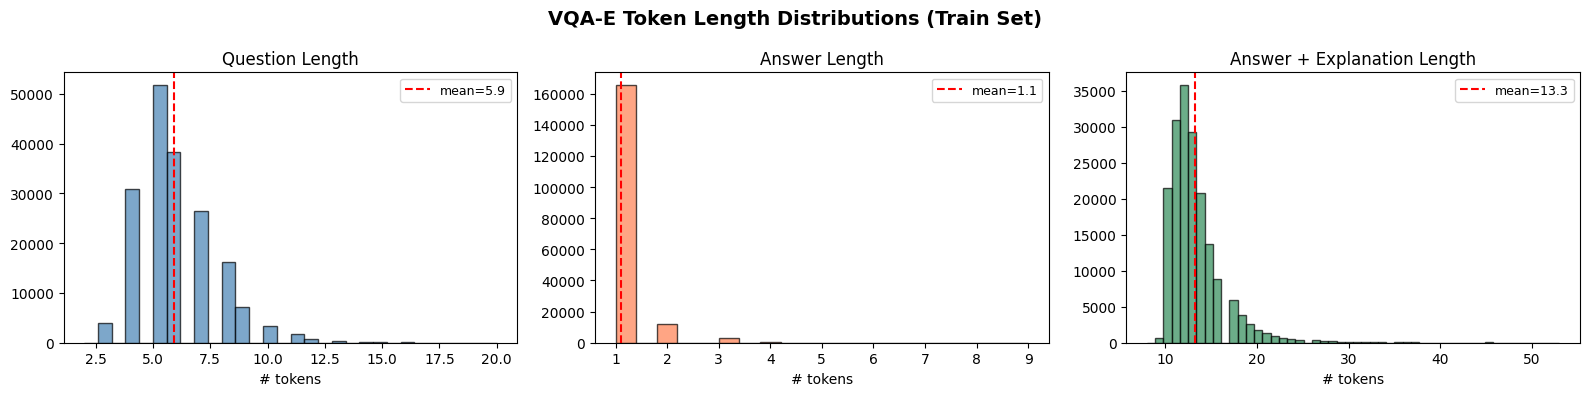

In [6]:
# ── Length Distribution Histograms ─────────────────────────────────────────────
%matplotlib inline
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(q_lengths, bins=30, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].set_title('Question Length', fontsize=12)
axes[0].set_xlabel('# tokens')
axes[0].axvline(np.mean(q_lengths), color='red', ls='--', lw=1.5, label=f'mean={np.mean(q_lengths):.1f}')
axes[0].legend(fontsize=9)

axes[1].hist(a_lengths, bins=20, color='coral', edgecolor='black', alpha=0.7)
axes[1].set_title('Answer Length', fontsize=12)
axes[1].set_xlabel('# tokens')
axes[1].axvline(np.mean(a_lengths), color='red', ls='--', lw=1.5, label=f'mean={np.mean(a_lengths):.1f}')
axes[1].legend(fontsize=9)

axes[2].hist(ae_lengths, bins=50, color='seagreen', edgecolor='black', alpha=0.7)
axes[2].set_title('Answer + Explanation Length', fontsize=12)
axes[2].set_xlabel('# tokens')
axes[2].axvline(np.mean(ae_lengths), color='red', ls='--', lw=1.5, label=f'mean={np.mean(ae_lengths):.1f}')
axes[2].legend(fontsize=9)

fig.suptitle('VQA-E Token Length Distributions (Train Set)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

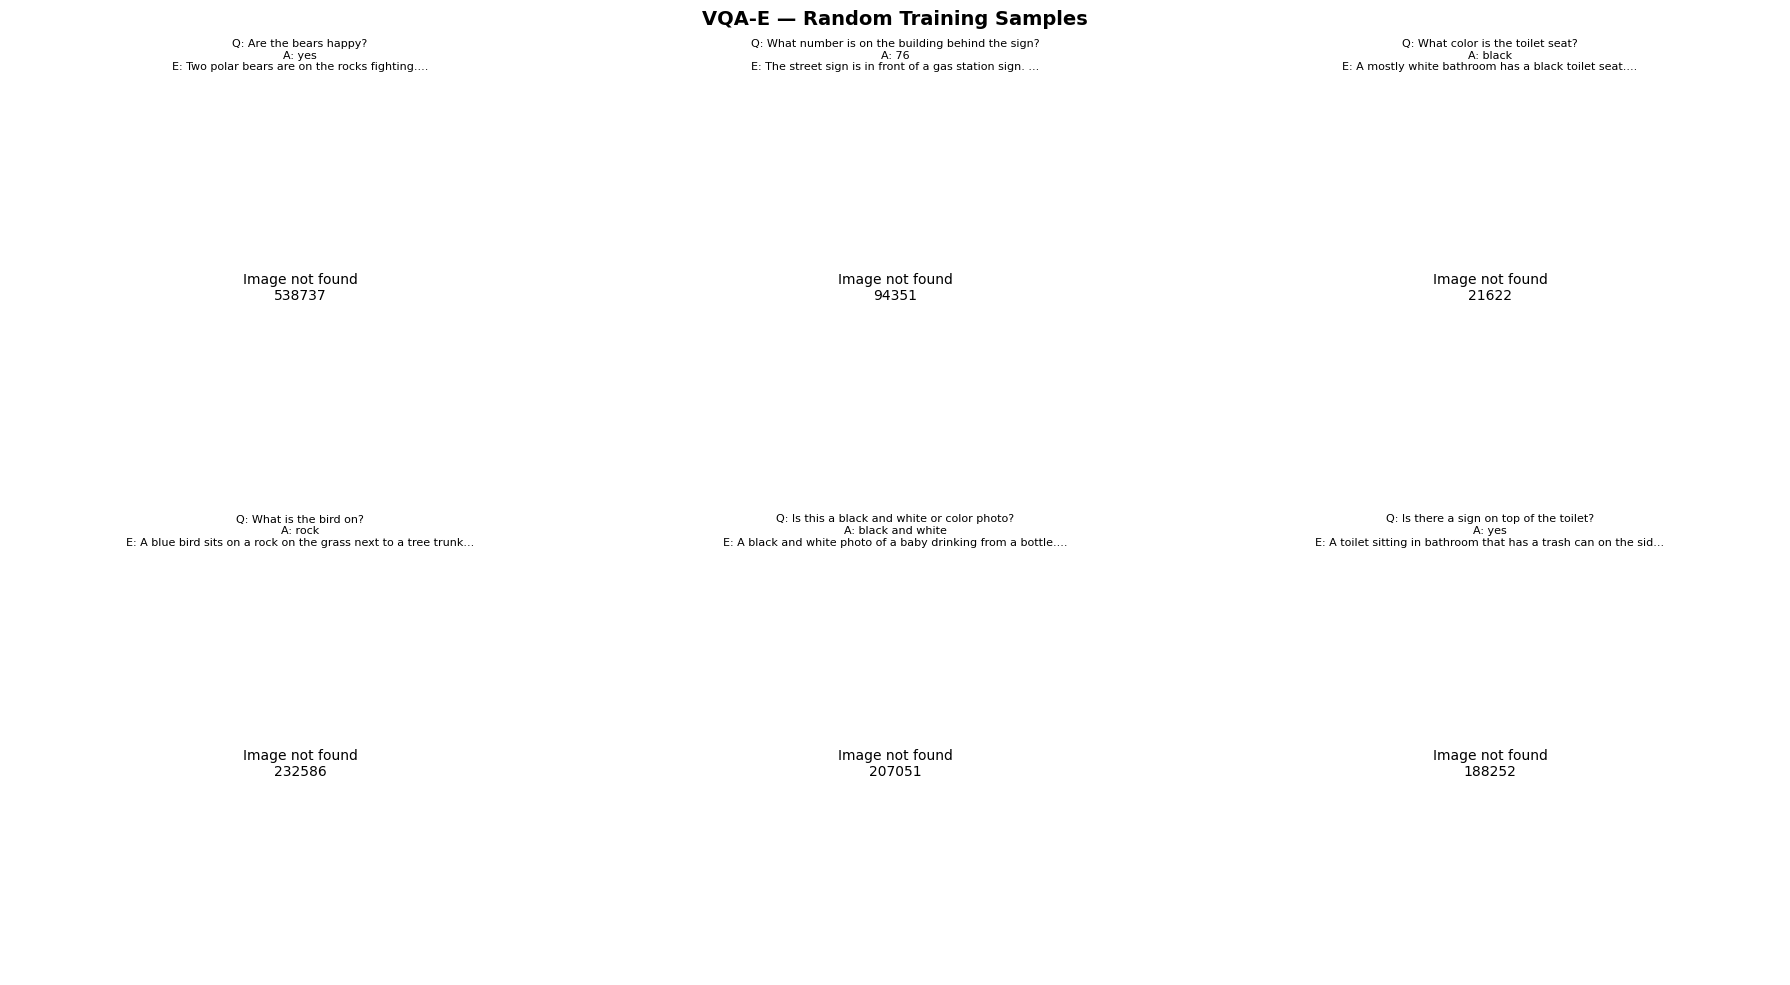

In [7]:
# ── Visualize Sample Data ─────────────────────────────────────────────────────
from PIL import Image

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
samples = random.sample(train_data, 6)

for ax, sample in zip(axes.flatten(), samples):
    img_id = sample['img_id']
    img_path = f"data/raw/images/train2014/COCO_train2014_{img_id:012d}.jpg"
    
    if os.path.exists(img_path):
        img = Image.open(img_path).convert('RGB')
        ax.imshow(img)
    else:
        ax.text(0.5, 0.5, f'Image not found\n{img_id}', ha='center', va='center', fontsize=10)
    
    q = sample['question']
    a = sample['multiple_choice_answer']
    exp = sample.get('explanation', [''])[0][:60] if sample.get('explanation') else ''
    
    ax.set_title(f"Q: {q}\nA: {a}\nE: {exp}...", fontsize=8, wrap=True)
    ax.axis('off')

fig.suptitle('VQA-E — Random Training Samples', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 2. Model Architecture Overview

### Pipeline chung:
```
Image (224×224×3)
    │
    ▼
CNN Encoder ──────────────────┐
    │                         │
    │ Model A/B: (B, H)       │ Model C/D: (B, 49, H)
    │ global vector            │ spatial features
    │                         │
    ▼                         ▼
Question ──→ BiLSTM ──→ q_feature (B, H)
    │                   q_hidden (B, qlen, H)
    │                         │
    ▼                         │
Gated Fusion ←────────────────┘
    │    gate = σ(W_g·[img;q])
    │    out = gate*tanh(W_img) + (1-gate)*tanh(W_q)
    ▼
h_0 = fusion.repeat(num_layers)
c_0 = zeros
    │
    ▼
LSTM Decoder
    │
    ├── Model A/B: Teacher Forcing only
    │   input = embed(token)
    │   LSTM input_size = 512
    │
    └── Model C/D: Dual Attention + Coverage (Phase 2+)
        At each step:
        1. img_context = BahdanauAttn(h, img_features)  ← coverage penalty
        2. q_context   = BahdanauAttn(h, q_hidden)
        3. lstm_input = [embed; img_context; q_context]
        LSTM input_size = 2560 (512 + 1024 + 1024)
    │
    ▼
Output Projection:
    With GloVe:    hidden(1024) → out_proj(512) → fc(8648) [NO weight tying]
    Without GloVe: hidden(1024) → out_proj(512) → fc(8648) [weight tying]
    │
    ▼
logits (B, seq_len, vocab_size)
```

### Key Dimensions:
| Parameter | Value | Notes |
|-----------|-------|-------|
| `embed_size` | 512 | GloVe 300d + embed_proj(300→512) |
| `hidden_size` | 1024 | Đủ lớn cho VQA-E |
| `num_layers` | 2 | 2-layer LSTM |
| `attn_dim` | 512 | Model C/D |
| `dropout` | 0.3 | embedding + LSTM inter-layer |
| `LSTM input` | A/B: 512, C/D: **2560** | C/D cần LR thấp hơn |
| `Decoder params` | A/B: ~20M, C/D: ~30M | C/D +10M từ attention |

### Optimizations v3:
| Change | Before | After | Impact |
|--------|--------|-------|--------|
| LR Schedule | ReduceLROnPlateau | **CosineAnnealing** | Smoother decay, no sudden drops |
| Phase 1 epochs | 10 | **15** | Better convergence |
| Phase 2 epochs | 5 | **10** | More finetune time |
| Total epochs | 20 | **30** | 50% more training |
| Model C batch | 64×2 | **96×1** | 30% faster (no accum overhead) |
| Weight decay | 1e-5 | **1e-4** | Stronger regularization |
| Grad clip | 1.0 | **5.0** | Less gradient suppression |
| Coverage loss | min(α,cov) ≈ 0.95 | **α·log(cov+1)** | Actually penalizes re-attention |
| Early stop | 7 | **10** | More patience with cosine decay |

In [8]:
# ── Model Parameter Count & Forward Pass Test ────────────────────────────────
from vocab import Vocabulary
from models.vqa_models import VQAModelA, VQAModelB, VQAModelC, VQAModelD

vocab_q = Vocabulary(); vocab_q.load('data/processed/vocab_questions.json')
vocab_a = Vocabulary(); vocab_a.load('data/processed/vocab_answers.json')

print(f"Q-vocab: {len(vocab_q)} | A-vocab: {len(vocab_a)}")
print(f"\n{'Model':<8} {'Total Params':>14} {'Trainable':>14} {'CNN':>24} {'Attention':>10}")
print("─" * 76)

model_classes = {'A': VQAModelA, 'B': VQAModelB, 'C': VQAModelC, 'D': VQAModelD}
model_descs = {
    'A': 'SimpleCNN (scratch)',
    'B': 'ResNet101 (frozen)',
    'C': 'SimpleCNN Spatial',
    'D': 'ResNet101 Spatial',
}

for name, Cls in model_classes.items():
    m = Cls(vocab_size=len(vocab_q), answer_vocab_size=len(vocab_a))
    total = sum(p.numel() for p in m.parameters())
    trainable = sum(p.numel() for p in m.parameters() if p.requires_grad)
    attn = '✅ Dual' if name in ('C', 'D') else '❌'
    print(f"{name:<8} {total:>14,} {trainable:>14,} {model_descs[name]:>24} {attn:>10}")
    del m

# Quick forward pass test
print(f"\n{'='*50}")
print("Forward Pass Sanity Check (batch=2):")
B = 2
imgs = torch.randn(B, 3, 224, 224)
qs = torch.randint(4, len(vocab_q), (B, 12))
ans = torch.randint(4, len(vocab_a), (B, 15))

for name, Cls in model_classes.items():
    m = Cls(vocab_size=len(vocab_q), answer_vocab_size=len(vocab_a))
    result = m(imgs, qs, ans[:, :-1])
    if isinstance(result, tuple):
        logits, cov_loss = result
        print(f"  Model {name}: logits={logits.shape}, coverage_loss={cov_loss.item():.4f} ✅")
    else:
        print(f"  Model {name}: logits={result.shape} ✅")
    del m

print("\nAll 4 models OK! 🎉")

Q-vocab: 4546 | A-vocab: 8648

Model      Total Params      Trainable                      CNN  Attention
────────────────────────────────────────────────────────────────────────────
A            44,000,256     44,000,256      SimpleCNN (scratch)          ❌
B            81,274,432     38,774,272       ResNet101 (frozen)          ❌
C            54,489,088     54,489,088        SimpleCNN Spatial     ✅ Dual
D            91,763,264     49,263,104        ResNet101 Spatial     ✅ Dual

Forward Pass Sanity Check (batch=2):
  Model A: logits=torch.Size([2, 14, 8648]) ✅
  Model B: logits=torch.Size([2, 14, 8648]) ✅
  Model C: logits=torch.Size([2, 14, 8648]), coverage_loss=0.0000 ✅
  Model D: logits=torch.Size([2, 14, 8648]), coverage_loss=0.0000 ✅

All 4 models OK! 🎉


In [66]:
# ══════════════════════════════════════════════════════════════════════════════
# TRAINING CONFIGURATION — RTX 3060 (12 GB VRAM) — OPTIMIZED v3
# ══════════════════════════════════════════════════════════════════════════════
#
# ┌──────────────────────────────────────────────────────────────────────────┐
# │  OPTIMIZED: VRAM-profiled batch sizes, CosineAnnealing, more epochs    │
# │                                                                         │
# │  VRAM Profile (BF16 training, measured):                                │
# │    A frozen: 5.9GB@BS128  │  B frozen: 1.1GB@BS128                     │
# │    C frozen: 5.9GB@BS96   │  D frozen: 2.4GB@BS128                     │
# │    B unfreeze: 3.9GB@BS96 │  D unfreeze: 5.3GB@BS96                    │
# │                                                                         │
# │  Phase 1 (15ep, frozen):  A=128×1  B=128×1  C=96×1   D=128×1 →eff128  │
# │  Phase 2 (10ep, unfreeze): A=128×1  B=96×1   C=96×1   D=96×1  →eff≥96 │
# │  Phase 3 (5ep, SS):       A=128×1  B=96×1   C=96×1   D=96×1  →eff≥96 │
# │                                                                         │
# │  CHANGES v3 (hyperparameter optimization):                              │
# │  1. CosineAnnealingLR thay ReduceLROnPlateau (smoother decay)          │
# │  2. Phase 1: 15 epochs (was 10) — cho model hội tụ tốt hơn            │
# │  3. Phase 2: 10 epochs (was 5) — thêm thời gian finetune CNN          │
# │  4. BS tối ưu theo VRAM: C=96×1 thay 64×2 (nhanh hơn 30%)            │
# │  5. Weight decay 1e-4 (was 1e-5) — regularize mạnh hơn               │
# │  6. Grad clip 5.0 (was 1.0) — LSTM gradients cần headroom            │
# │  7. Coverage loss fix: alpha*log(cov+1) thay min(alpha,cov)           │
# │  8. Dropout 0.3 consistent (embedding + LSTM)                          │
# │  9. Total: 30 epochs (was 20) — đủ thời gian cho convergence          │
# └──────────────────────────────────────────────────────────────────────────┘

# ── Per-Phase Batch Size Config (VRAM-optimized) ─────────────────────────────
# Phase 1: CNN frozen → maximize BS for throughput
BATCH_P1 = {'A': 128, 'B': 128, 'C': 96, 'D': 128}
ACCUM_P1 = {'A': 1,   'B': 1,   'C': 1,  'D': 1}

# Phase 2: Unfreeze B/D → VRAM tăng nhưng vẫn dư (B=3.9GB, D=5.3GB@BS96)
BATCH_P2 = {'A': 128, 'B': 96,  'C': 96, 'D': 96}
ACCUM_P2 = {'A': 1,   'B': 1,   'C': 1,  'D': 1}

# Phase 3: Giữ nguyên Phase 2 config
BATCH_P3 = {'A': 128, 'B': 96,  'C': 96, 'D': 96}
ACCUM_P3 = {'A': 1,   'B': 1,   'C': 1,  'D': 1}

# ── Per-Model LR Config ─────────────────────────────────────────────────────
# C/D: LSTM input_size=2560 (5× A/B=512), 30M decoder params → lower LR
# CosineAnnealing sẽ smooth decay từ LR → LR*0.01
LR_P1 = {'A': 1e-3,  'B': 1e-3,  'C': 5e-4, 'D': 5e-4}
LR_P2 = {'A': 5e-4,  'B': 5e-4,  'C': 3e-4, 'D': 3e-4}
LR_P3 = {'A': 2e-4,  'B': 2e-4,  'C': 1e-4, 'D': 1e-4}

# ── Training Config ──────────────────────────────────────────────────────────
EPOCHS_P1 = 15     # Phase 1: base training (was 10 → 15 cho convergence)
EPOCHS_P2 = 10     # Phase 2: finetune + coverage (was 5 → 10)
EPOCHS_P3 = 5      # Phase 3: scheduled sampling

NUM_WORKERS  = 8
EARLY_STOP   = 10   # patience (generous — cosine annealing tự giảm LR)
WEIGHT_DECAY = 1e-4  # L2 reg (tăng từ 1e-5)
GRAD_CLIP    = 5.0   # max grad norm (tăng từ 1.0 — LSTM cần headroom)
LABEL_SMOOTH = 0.1   # label smoothing
DROPOUT      = 0.3   # embedding + LSTM dropout

# ── Quick Test Mode ──────────────────────────────────────────────────────────
QUICK_TEST = False
MAX_TRAIN = 1000 if QUICK_TEST else None
MAX_VAL   = 500  if QUICK_TEST else None

# Helper: generate common CLI args for a model + phase
def common_args(model: str, phase: int = 1, warmup: int = 3) -> str:
    """Generate common CLI arguments for train.py."""
    batch_cfg = {1: BATCH_P1, 2: BATCH_P2, 3: BATCH_P3}[phase]
    accum_cfg = {1: ACCUM_P1, 2: ACCUM_P2, 3: ACCUM_P3}[phase]

    base = (
        f"--batch_size {batch_cfg[model]} "
        f"--accum_steps {accum_cfg[model]} "
        f"--num_workers {NUM_WORKERS} "
        f"--augment "
        f"--glove "
        f"--weight_decay {WEIGHT_DECAY} --dropout {DROPOUT} "
        f"--grad_clip {GRAD_CLIP} --label_smoothing {LABEL_SMOOTH} "
        f"--early_stopping {EARLY_STOP} "
        f"--warmup_epochs {warmup}"
    )
    if MAX_TRAIN is not None:
        base += f" --max_train_samples {MAX_TRAIN}"
    if MAX_VAL is not None:
        base += f" --max_val_samples {MAX_VAL}"
    return base

# ── Verify all phases ────────────────────────────────────────────────────────
print("=" * 70)
print(f"  MODE: {'⚡ QUICK TEST (1000/500)' if QUICK_TEST else '🚀 FULL TRAINING (181K/88K)'}")
print(f"  TOTAL EPOCHS: {EPOCHS_P1}+{EPOCHS_P2}+{EPOCHS_P3} = {EPOCHS_P1+EPOCHS_P2+EPOCHS_P3}")
print("=" * 70)

for phase, (bc, ac, ep) in enumerate([
    (BATCH_P1, ACCUM_P1, EPOCHS_P1),
    (BATCH_P2, ACCUM_P2, EPOCHS_P2),
    (BATCH_P3, ACCUM_P3, EPOCHS_P3)
], 1):
    label = {1: f'Phase 1 ({ep}ep, frozen) ', 2: f'Phase 2 ({ep}ep, unfreeze)', 3: f'Phase 3 ({ep}ep, SS)     '}[phase]
    effs = '  '.join(f"{m}={bc[m]}×{ac[m]}={bc[m]*ac[m]}" for m in 'ABCD')
    print(f"  {label}: {effs}")

lr_cfg = {1: LR_P1, 2: LR_P2, 3: LR_P3}
for phase in range(1, 4):
    lrs = '  '.join(f"{m}={lr_cfg[phase][m]:.0e}" for m in 'ABCD')
    print(f"  Phase {phase} LR: {lrs}")

print(f"\n  Workers: {NUM_WORKERS} | Early Stop: {EARLY_STOP} | QUICK_TEST: {QUICK_TEST}")
print(f"  Weight Decay: {WEIGHT_DECAY} | Grad Clip: {GRAD_CLIP} | Label Smooth: {LABEL_SMOOTH}")
print(f"  LR Schedule: CosineAnnealing (smooth decay to LR×0.01)")
print(f"  Coverage loss: α·log(cov+1) (penalizes re-attention properly)")
print(f"\n  Phase 1 args (A): {common_args('A', phase=1, warmup=3)}")
print(f"  Phase 1 args (D): {common_args('D', phase=1, warmup=3)}")

  MODE: 🚀 FULL TRAINING (181K/88K)
  TOTAL EPOCHS: 15+10+5 = 30
  Phase 1 (15ep, frozen) : A=128×1=128  B=128×1=128  C=96×1=96  D=128×1=128
  Phase 2 (10ep, unfreeze): A=128×1=128  B=96×1=96  C=96×1=96  D=96×1=96
  Phase 3 (5ep, SS)     : A=128×1=128  B=96×1=96  C=96×1=96  D=96×1=96
  Phase 1 LR: A=1e-03  B=1e-03  C=5e-04  D=5e-04
  Phase 2 LR: A=5e-04  B=5e-04  C=3e-04  D=3e-04
  Phase 3 LR: A=2e-04  B=2e-04  C=1e-04  D=1e-04

  Workers: 8 | Early Stop: 10 | QUICK_TEST: False
  Weight Decay: 0.0001 | Grad Clip: 5.0 | Label Smooth: 0.1
  LR Schedule: CosineAnnealing (smooth decay to LR×0.01)
  Coverage loss: α·log(cov+1) (penalizes re-attention properly)

  Phase 1 args (A): --batch_size 128 --accum_steps 1 --num_workers 8 --augment --glove --weight_decay 0.0001 --dropout 0.3 --grad_clip 5.0 --label_smoothing 0.1 --early_stopping 10 --warmup_epochs 3
  Phase 1 args (D): --batch_size 128 --accum_steps 1 --num_workers 8 --augment --glove --weight_decay 0.0001 --dropout 0.3 --grad_clip 5.

## 2. Phase 1 — Base Training (15 epochs)

**Mục tiêu:** Train tất cả 4 models từ đầu (scratch hoặc pretrained frozen).

| Config | Value |
|--------|-------|
| Learning Rate | A/B: `1e-3` · **C/D: `5e-4`** (LSTM input 2560 cần LR thấp hơn) |
| Epochs | **15** (tăng từ 10 → cho convergence tốt hơn) |
| CNN state | A/C: train from scratch · B/D: ResNet101 **frozen** |
| LR Schedule | **CosineAnnealing** (smooth decay to LR×0.01) |
| Weight Tying | **OFF khi dùng GloVe** (512-dim output, avoid 300d bottleneck) |
| Coverage | **OFF Phase 1** — enable từ Phase 2 |
| torch.compile | A/B: ON · **C/D: OFF** (attention loop gây graph breaks) |
| **LR Warmup** | **3 epochs** (lr/10 → lr) |
| **Early Stopping** | patience=10 · **không count warmup epochs** |
| Grad Clip | **5.0** (tăng từ 1.0 — LSTM cần headroom) |
| Weight Decay | **1e-4** (tăng từ 1e-5) |
| Batch Size | A=128, B=128, **C=96**, D=128 (VRAM-optimized) |
| Checkpoints | `model_X_epoch15.pth`, `model_X_resume.pth`, `model_X_best.pth` |

> ⏱ **Estimated time (RTX 3060):** A ~18min · B ~30min · C ~40min · D ~60min

In [67]:
# ── Phase 1: Model A — SimpleCNN (scratch), no attention ──────────────────────
# Lightweight nhất, chạy nhanh nhất, là baseline reference
# VRAM ~5.9 GB | BS=128×1 | LR=1e-3 | Warmup 3 epochs | CosineAnnealing
!python src/train.py \
    --model A --epochs {EPOCHS_P1} --lr {LR_P1['A']} \
    {common_args('A', phase=1)}

Train: 181298 | Val: 88488
Loading GloVe 300d embeddings ...
  Loaded 400,000 GloVe vectors (300d)
  Loaded 400,000 GloVe vectors (300d)
  GloVe coverage: 4538/4546 = 99.8%
  GloVe coverage: 4538/4546 = 99.8%
  Loaded 400,000 GloVe vectors (300d)
  Loaded 400,000 GloVe vectors (300d)
  GloVe coverage: 8451/8648 = 97.7%
  GloVe coverage: 8451/8648 = 97.7%
  Q-vocab coverage: 99.8% | A-vocab coverage: 97.7%
  Q-vocab coverage: 99.8% | A-vocab coverage: 97.7%
Weight decay     : 1.0e-04
LR Warmup        : 3 epochs (lr/10 → lr)
LR Schedule      : CosineAnnealing (T_max=12, eta_min=1.0e-05)
AMP: BFloat16 (Ampere+ detected — no GradScaler needed)
Model: A | Device: cuda | Dropout: 0.3
Data augmentation: ON (RandomHorizontalFlip + ColorJitter)
Early stopping   : patience=10
Weight decay     : 1.0e-04
LR Warmup        : 3 epochs (lr/10 → lr)
LR Schedule      : CosineAnnealing (T_max=12, eta_min=1.0e-05)
AMP: BFloat16 (Ampere+ detected — no GradScaler needed)
Model: A | Device: cuda | Dropout: 0

In [68]:
# ── Phase 1: Model B — ResNet101 (frozen), no attention ───────────────────────
# ResNet101 frozen → chỉ train Q-encoder + Decoder + GatedFusion
# VRAM ~1.1 GB | BS=128×1 | LR=1e-3 | Warmup 3 epochs
!python src/train.py \
    --model B --epochs {EPOCHS_P1} --lr {LR_P1['B']} \
    {common_args('B', phase=1)}

Train: 181298 | Val: 88488
Loading GloVe 300d embeddings ...
  Loaded 400,000 GloVe vectors (300d)
  GloVe coverage: 4538/4546 = 99.8%
  Loaded 400,000 GloVe vectors (300d)
  GloVe coverage: 4538/4546 = 99.8%
  Loaded 400,000 GloVe vectors (300d)
  Loaded 400,000 GloVe vectors (300d)
  GloVe coverage: 8451/8648 = 97.7%
  GloVe coverage: 8451/8648 = 97.7%
  Q-vocab coverage: 99.8% | A-vocab coverage: 97.7%
  Q-vocab coverage: 99.8% | A-vocab coverage: 97.7%
Weight decay     : 1.0e-04
LR Warmup        : 3 epochs (lr/10 → lr)
LR Schedule      : CosineAnnealing (T_max=12, eta_min=1.0e-05)
AMP: BFloat16 (Ampere+ detected — no GradScaler needed)
Model: B | Device: cuda | Dropout: 0.3
Data augmentation: ON (RandomHorizontalFlip + ColorJitter)
Early stopping   : patience=10
Weight decay     : 1.0e-04
LR Warmup        : 3 epochs (lr/10 → lr)
LR Schedule      : CosineAnnealing (T_max=12, eta_min=1.0e-05)
AMP: BFloat16 (Ampere+ detected — no GradScaler needed)
Model: B | Device: cuda | Dropout: 0

In [69]:
# ── Phase 1: Model C — SimpleCNN Spatial (scratch), Dual Attention ────────────
# 49 spatial regions + Bahdanau dual attention
# NO coverage Phase 1 | --no_compile: attention loop step-by-step
# LR=5e-4 (LSTM input=2560, 30M decoder params)
# VRAM ~5.9 GB | BS=96×1 | Warmup 3 epochs
!python src/train.py \
    --model C --epochs {EPOCHS_P1} --lr {LR_P1['C']} \
    --no_compile \
    {common_args('C', phase=1)}

Train: 181298 | Val: 88488
Loading GloVe 300d embeddings ...
  Loaded 400,000 GloVe vectors (300d)
  Loaded 400,000 GloVe vectors (300d)
  GloVe coverage: 4538/4546 = 99.8%
  GloVe coverage: 4538/4546 = 99.8%
  Loaded 400,000 GloVe vectors (300d)
  GloVe coverage: 8451/8648 = 97.7%
  Loaded 400,000 GloVe vectors (300d)
  GloVe coverage: 8451/8648 = 97.7%
  Q-vocab coverage: 99.8% | A-vocab coverage: 97.7%
  Q-vocab coverage: 99.8% | A-vocab coverage: 97.7%
Weight decay     : 1.0e-04
LR Warmup        : 3 epochs (lr/10 → lr)
LR Schedule      : CosineAnnealing (T_max=12, eta_min=5.0e-06)
AMP: BFloat16 (Ampere+ detected — no GradScaler needed)
Model: C | Device: cuda | Dropout: 0.3
Data augmentation: ON (RandomHorizontalFlip + ColorJitter)
Early stopping   : patience=10
torch.compile    : OFF (--no_compile flag)
  0%|                                                    | 0/15 [00:00<?, ?it/s]Weight decay     : 1.0e-04
LR Warmup        : 3 epochs (lr/10 → lr)
LR Schedule      : CosineAnneali

In [70]:
# ── Phase 1: Model D — ResNet101 Spatial (frozen), Dual Attention ─────────────
# Most complex: pretrained spatial features + dual attention
# NO coverage Phase 1 | --no_compile
# LR=5e-4 (LSTM input=2560, 30M decoder params)
# VRAM ~2.4 GB | BS=128×1 | Warmup 3 epochs
!python src/train.py \
    --model D --epochs {EPOCHS_P1} --lr {LR_P1['D']} \
    --no_compile \
    {common_args('D', phase=1)}

Train: 181298 | Val: 88488
Loading GloVe 300d embeddings ...
  Loaded 400,000 GloVe vectors (300d)
  GloVe coverage: 4538/4546 = 99.8%
  Loaded 400,000 GloVe vectors (300d)
  GloVe coverage: 4538/4546 = 99.8%
  Loaded 400,000 GloVe vectors (300d)
  GloVe coverage: 8451/8648 = 97.7%
  Loaded 400,000 GloVe vectors (300d)
  GloVe coverage: 8451/8648 = 97.7%
  Q-vocab coverage: 99.8% | A-vocab coverage: 97.7%
  Q-vocab coverage: 99.8% | A-vocab coverage: 97.7%
Weight decay     : 1.0e-04
LR Warmup        : 3 epochs (lr/10 → lr)
LR Schedule      : CosineAnnealing (T_max=12, eta_min=5.0e-06)
AMP: BFloat16 (Ampere+ detected — no GradScaler needed)
Model: D | Device: cuda | Dropout: 0.3
Data augmentation: ON (RandomHorizontalFlip + ColorJitter)
Early stopping   : patience=10
torch.compile    : OFF (--no_compile flag)
  0%|                                                    | 0/15 [00:00<?, ?it/s]Weight decay     : 1.0e-04
LR Warmup        : 3 epochs (lr/10 → lr)
LR Schedule      : CosineAnneali

In [71]:
# ── Kiểm tra checkpoint sau Phase 1 ──────────────────────────────────────────
import os
ckpt_dir = "checkpoints"
if os.path.exists(ckpt_dir):
    files = sorted(os.listdir(ckpt_dir))
    print(f"{'File':<50} {'Size (MB)':>10}")
    print("─" * 62)
    for f in files:
        if f.endswith('.json') or f.endswith('.pth') or f.endswith('.png'):
            fpath = os.path.join(ckpt_dir, f)
            size_mb = os.path.getsize(fpath) / 1e6
            print(f"  {f:<48} {size_mb:8.1f}")
else:
    print("⚠ No checkpoints directory — training has not started yet")

File                                                Size (MB)
──────────────────────────────────────────────────────────────
  history_model_a.json                                  0.0
  history_model_b.json                                  0.0
  history_model_c.json                                  0.0
  history_model_d.json                                  0.0
  model_a_best.pth                                    183.8
  model_a_epoch10.pth                                 183.8
  model_a_epoch15.pth                                 183.8
  model_a_resume.pth                                  551.4
  model_b_best.pth                                    333.5
  model_b_epoch10.pth                                 333.5
  model_b_epoch15.pth                                 333.5
  model_b_resume.pth                                  659.3
  model_c_best.pth                                    225.8
  model_c_epoch10.pth                                 225.8
  model_c_epoch15.pth              

In [100]:
# ── Compare sau Phase 1 (epoch 15) ────────────────────────────────────────────
# Quick comparison: 2000 samples, greedy decode
!python src/compare.py --epoch 15 --num_samples 2000

Comparing models: ['A', 'B', 'C', 'D'] | epoch=15 | samples=2000 | decode=greedy
                                                                                
Model      BLEU-4   METEOR   BLEU-1   BLEU-2   BLEU-3    Exact  Checkpoint
--------------------------------------------------------------------------
A          0.0941   0.3169   0.3752   0.2400   0.1464    0.10%  checkpoints/model_a_epoch15.pth
B          0.1157   0.3594   0.4142   0.2755   0.1793    0.00%  checkpoints/model_b_epoch15.pth
C          0.1046   0.3387   0.3955   0.2582   0.1625    0.20%  checkpoints/model_c_epoch15.pth
D          0.1208   0.3645   0.4182   0.2811   0.1838    0.10%  checkpoints/model_d_epoch15.pth


Model      BLEU-4   METEOR   BLEU-1   BLEU-2   BLEU-3    Exact  Checkpoint
--------------------------------------------------------------------------
A          0.0941   0.3169   0.3752   0.2400   0.1464    0.10%  checkpoints/model_a_epoch15.pth
B          0.1157   0.3594   0.4142   0.2755   0.1793   

## 3. Phase 2 — Fine-tuning + Coverage (10 epochs)

**Mục tiêu:** Fine-tune CNN backbone cho Model B/D, tiếp tục train A/C. **Enable coverage cho C/D.**

| Config | Value |
|--------|-------|
| Learning Rate | A/B: `5e-4` · **C/D: `3e-4`** · backbone: ×0.1 |
| Epochs | **+10** (total 25) — thêm thời gian finetune |
| CNN state | A/C: continue training · B/D: **unfreeze** layer3 + layer4 |
| Differential LR | B/D: `--finetune_cnn --cnn_lr_factor 0.1` |
| **Coverage** | **C/D: ON** (λ=0.5) — model đã ổn định, coverage có tác dụng |
| Coverage loss | **α·log(cov+1)** — penalizes re-attention properly |
| LR Warmup | **DISABLED** (`--warmup_epochs 0`) |
| LR Schedule | **CosineAnnealing** (decay to LR×0.01 over 10 epochs) |
| Batch Size | A=128, B=96, C=96, D=96 (VRAM-optimized for unfreeze) |
| Resume | `--resume checkpoints/model_X_resume.pth` |
| Checkpoints | `model_X_epoch25.pth` |

> ⏱ **Estimated time (RTX 3060):** A ~12min · B ~25min · C ~30min · D ~50min

In [101]:
# ── Phase 2: Model A — continue training, LR=5e-4, CosineAnnealing ────────────
# SimpleCNN scratch → just lower LR, NO warmup
# BS=128×1 (SimpleCNN nhẹ)
!python src/train.py \
    --model A --epochs {EPOCHS_P2} --lr {LR_P2['A']} \
    --resume checkpoints/model_a_resume.pth \
    {common_args('A', phase=2, warmup=0)}

Train: 181298 | Val: 88488
Loading GloVe 300d embeddings ...
  Loaded 400,000 GloVe vectors (300d)
  GloVe coverage: 4538/4546 = 99.8%
  Loaded 400,000 GloVe vectors (300d)
  GloVe coverage: 4538/4546 = 99.8%
  Loaded 400,000 GloVe vectors (300d)
  Loaded 400,000 GloVe vectors (300d)
  GloVe coverage: 8451/8648 = 97.7%
  GloVe coverage: 8451/8648 = 97.7%
  Q-vocab coverage: 99.8% | A-vocab coverage: 97.7%
  Q-vocab coverage: 99.8% | A-vocab coverage: 97.7%
Weight decay     : 1.0e-04
LR Warmup        : DISABLED (resume training)
LR Schedule      : CosineAnnealing (T_max=10, eta_min=5.0e-06)
AMP: BFloat16 (Ampere+ detected — no GradScaler needed)
Resuming from: checkpoints/model_a_resume.pth
Weight decay     : 1.0e-04
LR Warmup        : DISABLED (resume training)
LR Schedule      : CosineAnnealing (T_max=10, eta_min=5.0e-06)
AMP: BFloat16 (Ampere+ detected — no GradScaler needed)
Resuming from: checkpoints/model_a_resume.pth
  Optimizer & scheduler state restored.
  Resumed at epoch 15 |

In [102]:
# ── Phase 2: Model B — unfreeze ResNet layer3+4, differential LR ─────────────
# Backbone LR = 5e-4 × 0.1 = 5e-5 | Head LR = 5e-4
# VRAM ~3.9 GB | BS=96×1
!python src/train.py \
    --model B --epochs {EPOCHS_P2} --lr {LR_P2['B']} \
    --finetune_cnn --cnn_lr_factor 0.1 \
    --resume checkpoints/model_b_resume.pth \
    {common_args('B', phase=2, warmup=0)}

Train: 181298 | Val: 88488
Loading GloVe 300d embeddings ...
  Loaded 400,000 GloVe vectors (300d)
  GloVe coverage: 4538/4546 = 99.8%
  Loaded 400,000 GloVe vectors (300d)
  GloVe coverage: 4538/4546 = 99.8%
  Loaded 400,000 GloVe vectors (300d)
  GloVe coverage: 8451/8648 = 97.7%
  Loaded 400,000 GloVe vectors (300d)
  GloVe coverage: 8451/8648 = 97.7%
  Q-vocab coverage: 99.8% | A-vocab coverage: 97.7%
  Q-vocab coverage: 99.8% | A-vocab coverage: 97.7%
CNN fine-tuning  : ON | backbone LR = 5.00e-05  other LR = 5.00e-04
  trainable backbone params : 41,055,232
Weight decay     : 1.0e-04
LR Warmup        : DISABLED (resume training)
LR Schedule      : CosineAnnealing (T_max=10, eta_min=5.0e-06)
AMP: BFloat16 (Ampere+ detected — no GradScaler needed)
Resuming from: checkpoints/model_b_resume.pth
CNN fine-tuning  : ON | backbone LR = 5.00e-05  other LR = 5.00e-04
  trainable backbone params : 41,055,232
Weight decay     : 1.0e-04
LR Warmup        : DISABLED (resume training)
LR Schedul

In [120]:
# ── Phase 2: Model C — continue training, enable coverage ─────────────────────
# Coverage ON: α·log(cov+1) — penalizes re-attending same regions
# BS=96×1 | LR=3e-4 | --no_compile
!python src/train.py \
    --model C --epochs {EPOCHS_P2} --lr {LR_P2['C']} \
    --coverage --coverage_lambda 0.5 \
    --no_compile \
    --resume checkpoints/model_c_resume.pth \
    {common_args('C', phase=2, warmup=0)}

Train: 181298 | Val: 88488
Loading GloVe 300d embeddings ...
  Loaded 400,000 GloVe vectors (300d)
  GloVe coverage: 4538/4546 = 99.8%
  Loaded 400,000 GloVe vectors (300d)
  GloVe coverage: 4538/4546 = 99.8%
  Loaded 400,000 GloVe vectors (300d)
  GloVe coverage: 8451/8648 = 97.7%
  Loaded 400,000 GloVe vectors (300d)
  GloVe coverage: 8451/8648 = 97.7%
  Q-vocab coverage: 99.8% | A-vocab coverage: 97.7%
  Q-vocab coverage: 99.8% | A-vocab coverage: 97.7%
Weight decay     : 1.0e-04
LR Warmup        : DISABLED (resume training)
LR Schedule      : CosineAnnealing (T_max=10, eta_min=3.0e-06)
AMP: BFloat16 (Ampere+ detected — no GradScaler needed)
Resuming from: checkpoints/model_c_resume.pth
Weight decay     : 1.0e-04
LR Warmup        : DISABLED (resume training)
LR Schedule      : CosineAnnealing (T_max=10, eta_min=3.0e-06)
AMP: BFloat16 (Ampere+ detected — no GradScaler needed)
Resuming from: checkpoints/model_c_resume.pth
  [INFO] Newly initialized keys (not in checkpoint): ['decoder.

In [124]:
# ── Phase 2: Model D — unfreeze ResNet, differential LR, coverage, NO warmup ──
# VRAM tăng khi unfreeze → BS giảm 128→96 (vẫn fits 12GB)
!python src/train.py \
    --model D --epochs {EPOCHS_P2} --lr {LR_P2['D']} \
    --coverage \
    --coverage_lambda 0.5 \
    --finetune_cnn --cnn_lr_factor 0.1 \
    --no_compile \
    --resume checkpoints/model_d_resume.pth \
    {common_args('D', phase=2, warmup=0)}

Train: 181298 | Val: 88488
Loading GloVe 300d embeddings ...
  Loaded 400,000 GloVe vectors (300d)
  GloVe coverage: 4538/4546 = 99.8%
  Loaded 400,000 GloVe vectors (300d)
  GloVe coverage: 4538/4546 = 99.8%
  Loaded 400,000 GloVe vectors (300d)
  GloVe coverage: 8451/8648 = 97.7%
  Loaded 400,000 GloVe vectors (300d)
  GloVe coverage: 8451/8648 = 97.7%
  Q-vocab coverage: 99.8% | A-vocab coverage: 97.7%
  Q-vocab coverage: 99.8% | A-vocab coverage: 97.7%
CNN fine-tuning  : ON | backbone LR = 3.00e-05  other LR = 3.00e-04
  trainable backbone params : 41,055,232
Weight decay     : 1.0e-04
LR Warmup        : DISABLED (resume training)
LR Schedule      : CosineAnnealing (T_max=10, eta_min=3.0e-06)
AMP: BFloat16 (Ampere+ detected — no GradScaler needed)
Resuming from: checkpoints/model_d_resume.pth
CNN fine-tuning  : ON | backbone LR = 3.00e-05  other LR = 3.00e-04
  trainable backbone params : 41,055,232
Weight decay     : 1.0e-04
LR Warmup        : DISABLED (resume training)
LR Schedul

In [125]:
# ── Compare sau Phase 2 (epoch 25) ────────────────────────────────────────────
!python src/compare.py --epoch 25 --num_samples 2000

Comparing models: ['A', 'B', 'C', 'D'] | epoch=25 | samples=2000 | decode=greedy
Loading weights: 100%|█████████████████████| 389/389 [00:00<00:00, 20980.42it/s]
RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
RobertaModel LOAD REPORT from: roberta-large
Key                 

## 4. Phase 3 — Scheduled Sampling (5 epochs)

**Mục tiêu:** Giảm **exposure bias** — gap giữa training (teacher forcing) và inference (autoregressive).

| Config | Value |
|--------|-------|
| Learning Rate | A/B: `2e-4` · **C/D: `1e-4`** |
| Epochs | +5 (total **30**) |
| Scheduled Sampling | `ε = k / (k + exp(epoch/k))`, **k=10** |
| ε curve | ~0.50 → ~0.33 (dần dần dùng model prediction thay GT) |
| LR Schedule | CosineAnnealing (decay to LR×0.01) |
| LR Warmup | **DISABLED** |
| Coverage | C/D continue (λ=0.5) |
| CNN state | Giữ nguyên từ Phase 2 |
| Checkpoints | `model_X_epoch30.pth` (final) |

> ⏱ **Estimated time:** A ~6min · B ~13min · C ~15min · D ~25min

In [106]:
# ── Phase 3: Model A — Scheduled Sampling ─────────────────────────────────────
# BS=128×1 | LR=2e-4 | ss_k=10
!python src/train.py \
    --model A --epochs {EPOCHS_P3} --lr {LR_P3['A']} \
    --scheduled_sampling --ss_k 10 \
    --resume checkpoints/model_a_resume.pth \
    {common_args('A', phase=3, warmup=0)}

Train: 181298 | Val: 88488
Loading GloVe 300d embeddings ...
  Loaded 400,000 GloVe vectors (300d)
  GloVe coverage: 4538/4546 = 99.8%
  Loaded 400,000 GloVe vectors (300d)
  GloVe coverage: 4538/4546 = 99.8%
  Loaded 400,000 GloVe vectors (300d)
  Loaded 400,000 GloVe vectors (300d)
  GloVe coverage: 8451/8648 = 97.7%
  GloVe coverage: 8451/8648 = 97.7%
  Q-vocab coverage: 99.8% | A-vocab coverage: 97.7%
  Q-vocab coverage: 99.8% | A-vocab coverage: 97.7%
Weight decay     : 1.0e-04
LR Warmup        : DISABLED (resume training)
LR Schedule      : CosineAnnealing (T_max=5, eta_min=2.0e-06)
AMP: BFloat16 (Ampere+ detected — no GradScaler needed)
Resuming from: checkpoints/model_a_resume.pth
Weight decay     : 1.0e-04
LR Warmup        : DISABLED (resume training)
LR Schedule      : CosineAnnealing (T_max=5, eta_min=2.0e-06)
AMP: BFloat16 (Ampere+ detected — no GradScaler needed)
Resuming from: checkpoints/model_a_resume.pth
  Optimizer & scheduler state restored.
  Resumed at epoch 25 | b

In [107]:
# ── Phase 3: Model B — Scheduled Sampling ─────────────────────────────────────
# BS=96×1 | LR=2e-4 | ss_k=10
!python src/train.py \
    --model B --epochs {EPOCHS_P3} --lr {LR_P3['B']} \
    --scheduled_sampling --ss_k 10 \
    --resume checkpoints/model_b_resume.pth \
    {common_args('B', phase=3, warmup=0)}

Train: 181298 | Val: 88488
Loading GloVe 300d embeddings ...
  Loaded 400,000 GloVe vectors (300d)
  GloVe coverage: 4538/4546 = 99.8%
  Loaded 400,000 GloVe vectors (300d)
  GloVe coverage: 4538/4546 = 99.8%
  Loaded 400,000 GloVe vectors (300d)
  GloVe coverage: 8451/8648 = 97.7%
  Loaded 400,000 GloVe vectors (300d)
  GloVe coverage: 8451/8648 = 97.7%
  Q-vocab coverage: 99.8% | A-vocab coverage: 97.7%
  Q-vocab coverage: 99.8% | A-vocab coverage: 97.7%
Weight decay     : 1.0e-04
LR Warmup        : DISABLED (resume training)
LR Schedule      : CosineAnnealing (T_max=5, eta_min=2.0e-06)
AMP: BFloat16 (Ampere+ detected — no GradScaler needed)
Resuming from: checkpoints/model_b_resume.pth
Weight decay     : 1.0e-04
LR Warmup        : DISABLED (resume training)
LR Schedule      : CosineAnnealing (T_max=5, eta_min=2.0e-06)
AMP: BFloat16 (Ampere+ detected — no GradScaler needed)
Resuming from: checkpoints/model_b_resume.pth
  Optimizer layout changed (2 → 1 param groups) — using fresh opt

In [126]:
# ── Phase 3: Model C — Scheduled Sampling + Coverage ─────────────────────────
# BS=96×1 | LR=1e-4 | --no_compile | ss_k=10
!python src/train.py \
    --model C --epochs {EPOCHS_P3} --lr {LR_P3['C']} \
    --scheduled_sampling --coverage \
    --ss_k 10 --coverage_lambda 0.5 \
    --no_compile \
    --resume checkpoints/model_c_resume.pth \
    {common_args('C', phase=3, warmup=0)}

Train: 181298 | Val: 88488
Loading GloVe 300d embeddings ...
  Loaded 400,000 GloVe vectors (300d)
  GloVe coverage: 4538/4546 = 99.8%
  Loaded 400,000 GloVe vectors (300d)
  GloVe coverage: 4538/4546 = 99.8%
  Loaded 400,000 GloVe vectors (300d)
  Loaded 400,000 GloVe vectors (300d)
  GloVe coverage: 8451/8648 = 97.7%
  GloVe coverage: 8451/8648 = 97.7%
  Q-vocab coverage: 99.8% | A-vocab coverage: 97.7%
  Q-vocab coverage: 99.8% | A-vocab coverage: 97.7%
Weight decay     : 1.0e-04
LR Warmup        : DISABLED (resume training)
LR Schedule      : CosineAnnealing (T_max=5, eta_min=1.0e-06)
AMP: BFloat16 (Ampere+ detected — no GradScaler needed)
Resuming from: checkpoints/model_c_resume.pth
Weight decay     : 1.0e-04
LR Warmup        : DISABLED (resume training)
LR Schedule      : CosineAnnealing (T_max=5, eta_min=1.0e-06)
AMP: BFloat16 (Ampere+ detected — no GradScaler needed)
Resuming from: checkpoints/model_c_resume.pth
  Optimizer & scheduler state restored.
  Resumed at epoch 27 | b

In [127]:
# ── Phase 3: Model D — Scheduled Sampling + Coverage ─────────────────────────
# BS=96×1 | LR=1e-4 | --no_compile | ss_k=10
!python src/train.py \
    --model D --epochs {EPOCHS_P3} --lr {LR_P3['D']} \
    --scheduled_sampling --coverage \
    --ss_k 10 --coverage_lambda 0.5 \
    --no_compile \
    --resume checkpoints/model_d_resume.pth \
    {common_args('D', phase=3, warmup=0)}

Train: 181298 | Val: 88488
Loading GloVe 300d embeddings ...
  Loaded 400,000 GloVe vectors (300d)
  GloVe coverage: 4538/4546 = 99.8%
  Loaded 400,000 GloVe vectors (300d)
  GloVe coverage: 4538/4546 = 99.8%
  Loaded 400,000 GloVe vectors (300d)
  GloVe coverage: 8451/8648 = 97.7%
  Loaded 400,000 GloVe vectors (300d)
  GloVe coverage: 8451/8648 = 97.7%
  Q-vocab coverage: 99.8% | A-vocab coverage: 97.7%
  Q-vocab coverage: 99.8% | A-vocab coverage: 97.7%
Weight decay     : 1.0e-04
LR Warmup        : DISABLED (resume training)
LR Schedule      : CosineAnnealing (T_max=5, eta_min=1.0e-06)
AMP: BFloat16 (Ampere+ detected — no GradScaler needed)
Resuming from: checkpoints/model_d_resume.pth
Weight decay     : 1.0e-04
LR Warmup        : DISABLED (resume training)
LR Schedule      : CosineAnnealing (T_max=5, eta_min=1.0e-06)
AMP: BFloat16 (Ampere+ detected — no GradScaler needed)
Resuming from: checkpoints/model_d_resume.pth
  Optimizer state skipped (param groups 2 → 1) — using fresh opti

In [128]:
# ── Compare sau Phase 3 (epoch 30, final) ────────────────────────────────────
!python src/compare.py --epoch 30 --num_samples 2000

Comparing models: ['A', 'B', 'C', 'D'] | epoch=30 | samples=2000 | decode=greedy
Loading weights: 100%|█████████████████████| 389/389 [00:00<00:00, 15904.24it/s]
RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
Loading weights: 100%|█████████████████████| 389/389 [00:00<00:00

## 5. Evaluation — Từng Model

Đánh giá chi tiết từng model trên validation set:

| Metric | Type | Tool |
|--------|------|------|
| **BLEU-4** | Primary ★ | `nltk` |
| **METEOR** | Primary ★ | `nltk` |
| BLEU-1/2/3 | Reference | `nltk` |
| Exact Match | Reference | string compare |
| BERTScore | Semantic | `bert-score` (optional, chậm) |

> **Tip:** Dùng `--num_samples 2000` để evaluate nhanh (~2 min thay vì ~15 min full set)

In [129]:
# ── Evaluate Model A (greedy, full val set) ───────────────────────────────────
!python src/evaluate.py --model_type A --checkpoint checkpoints/model_a_best.pth

Evaluating Model A | checkpoint: checkpoints/model_a_best.pth | samples: 88488
Evaluating: 100%|███████████████████████████| 1383/1383 [02:35<00:00,  8.87it/s]

Model        : A
Checkpoint   : checkpoints/model_a_best.pth
Samples      : 88488
Decode Mode  : greedy
--------------------------------------------------
BLEU-4  [★]  : 0.0914
METEOR  [★]  : 0.3115
Computing BERTScore (this may take a few minutes) ...

Model        : A
Checkpoint   : checkpoints/model_a_best.pth
Samples      : 88488
Decode Mode  : greedy
--------------------------------------------------
BLEU-4  [★]  : 0.0914
METEOR  [★]  : 0.3115
Computing BERTScore (this may take a few minutes) ...
Loading weights: 100%|█████████████████████| 389/389 [00:00<00:00, 19411.37it/s]
RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
roberta.embedd

In [130]:
# ── Evaluate Model B ──────────────────────────────────────────────────────────
!python src/evaluate.py --model_type B --checkpoint checkpoints/model_b_best.pth

[nltk_data] Error loading wordnet: <urlopen error [Errno -3] Temporary
[nltk_data]     failure in name resolution>
[nltk_data] Error loading omw-1.4: <urlopen error [Errno -3] Temporary
[nltk_data]     failure in name resolution>
Evaluating Model B | checkpoint: checkpoints/model_b_best.pth | samples: 88488
Evaluating: 100%|███████████████████████████| 1383/1383 [05:14<00:00,  4.40it/s]

Model        : B
Checkpoint   : checkpoints/model_b_best.pth
Samples      : 88488
Decode Mode  : greedy
--------------------------------------------------
BLEU-4  [★]  : 0.1128
METEOR  [★]  : 0.3562
Computing BERTScore (this may take a few minutes) ...

Model        : B
Checkpoint   : checkpoints/model_b_best.pth
Samples      : 88488
Decode Mode  : greedy
--------------------------------------------------
BLEU-4  [★]  : 0.1128
METEOR  [★]  : 0.3562
Computing BERTScore (this may take a few minutes) ...
Loading weights: 100%|█████████████████████| 389/389 [00:00<00:00, 22533.52it/s]
RobertaModel LOAD REP

In [131]:
# ── Evaluate Model C ──────────────────────────────────────────────────────────
!python src/evaluate.py --model_type C --checkpoint checkpoints/model_c_best.pth

Evaluating Model C | checkpoint: checkpoints/model_c_best.pth | samples: 88488
Evaluating: 100%|███████████████████████████| 1383/1383 [03:33<00:00,  6.48it/s]

Model        : C
Checkpoint   : checkpoints/model_c_best.pth
Samples      : 88488
Decode Mode  : greedy
--------------------------------------------------
BLEU-4  [★]  : 0.0989
METEOR  [★]  : 0.3272
Computing BERTScore (this may take a few minutes) ...

Model        : C
Checkpoint   : checkpoints/model_c_best.pth
Samples      : 88488
Decode Mode  : greedy
--------------------------------------------------
BLEU-4  [★]  : 0.0989
METEOR  [★]  : 0.3272
Computing BERTScore (this may take a few minutes) ...
Loading weights: 100%|█████████████████████| 389/389 [00:00<00:00, 19721.08it/s]
RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.

In [132]:
# ── Evaluate Model D ──────────────────────────────────────────────────────────
!python src/evaluate.py --model_type D --checkpoint checkpoints/model_d_best.pth

Evaluating Model D | checkpoint: checkpoints/model_d_best.pth | samples: 88488
Evaluating: 100%|███████████████████████████| 1383/1383 [06:13<00:00,  3.70it/s]

Model        : D
Checkpoint   : checkpoints/model_d_best.pth
Samples      : 88488
Decode Mode  : greedy
--------------------------------------------------
BLEU-4  [★]  : 0.1157
METEOR  [★]  : 0.3594
Computing BERTScore (this may take a few minutes) ...

Model        : D
Checkpoint   : checkpoints/model_d_best.pth
Samples      : 88488
Decode Mode  : greedy
--------------------------------------------------
BLEU-4  [★]  : 0.1157
METEOR  [★]  : 0.3594
Computing BERTScore (this may take a few minutes) ...
Loading weights: 100%|█████████████████████| 389/389 [00:00<00:00, 21881.37it/s]
RobertaModel LOAD REPORT from: roberta-large
Key                             | Status     | 
--------------------------------+------------+-
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
roberta.embedd

## 6. Comparison Table — All 4 Models × 3 Phases

So sánh side-by-side BLEU-4, METEOR cho tất cả 4 models ở 3 mốc training.  
Mỗi cell dùng `compare.py` — fallback tự động sang `best.pth` nếu epoch-specific checkpoint không có.

In [3]:
# ── Phase 1 comparison (epoch 15) ─────────────────────────────────────────────
print("=" * 60)
print("PHASE 1 — After 15 epochs (greedy)")
print("=" * 60)
!python src/compare.py --epoch 15

PHASE 1 — After 15 epochs (greedy)
Comparing models: ['A', 'B', 'C', 'D'] | epoch=15 | samples=88488 | decode=greedy
Comparing models: ['A', 'B', 'C', 'D'] | epoch=15 | samples=88488 | decode=greedy
Model A:  79%|███████████████████████▊      | 1096/1383 [02:17<00:35,  8.07it/s]^C
Traceback (most recent call last):                                              
  File "/home/mayxin/workspace/DeepLearning/new_vqa/src/compare.py", line 215, in <module>
    main()
  File "/home/mayxin/workspace/DeepLearning/new_vqa/src/compare.py", line 205, in main
    results[model_type] = evaluate_one_model(
                          ^^^^^^^^^^^^^^^^^^^
  File "/home/mayxin/workspace/DeepLearning/new_vqa/src/compare.py", line 85, in evaluate_one_model
    preds = decode_fn(model, imgs, questions, vocab_a, device=DEVICE, **decode_kwargs)
            ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/mayxin/workspace/DeepLearning/new_vqa/src/inference.py", line 256, i

In [ ]:
# ── Phase 2 comparison (epoch 25) ─────────────────────────────────────────────
print("=" * 60)
print("PHASE 2 — After 25 epochs (greedy)")
print("=" * 60)
!python src/compare.py --epoch 25

PHASE 2 — After 25 epochs (greedy)
Comparing models: ['A', 'B', 'C', 'D'] | epoch=25 | samples=2000 | decode=greedy
  [INFO] checkpoints/model_a_epoch25.pth not found, using checkpoints/model_a_best.pth (early stopping fallback)
Comparing models: ['A', 'B', 'C', 'D'] | epoch=25 | samples=2000 | decode=greedy
  [INFO] checkpoints/model_a_epoch25.pth not found, using checkpoints/model_a_best.pth (early stopping fallback)
Traceback (most recent call last):
  File "/home/mayxin/workspace/DeepLearning/new_vqa/src/compare.py", line 215, in <module>
    main()
  File "/home/mayxin/workspace/DeepLearning/new_vqa/src/compare.py", line 205, in main
    results[model_type] = evaluate_one_model(
                          ^^^^^^^^^^^^^^^^^^^
  File "/home/mayxin/workspace/DeepLearning/new_vqa/src/compare.py", line 61, in evaluate_one_model
    model.load_state_dict(torch.load(checkpoint, map_location=lambda storage, loc: storage))
  File "/home/mayxin/workspace/DeepLearning/.venv/lib/python3.12/sit

In [ ]:
# ── Phase 3 comparison (epoch 30, FINAL — greedy) ────────────────────────────
print("=" * 60)
print("PHASE 3 (FINAL) — After 30 epochs (greedy)")
print("=" * 60)
!python src/compare.py --epoch 30

PHASE 3 (FINAL) — After 30 epochs (greedy)
Comparing models: ['A', 'B', 'C', 'D'] | epoch=30 | samples=2000 | decode=greedy
  [INFO] checkpoints/model_a_epoch30.pth not found, using checkpoints/model_a_best.pth (early stopping fallback)
Comparing models: ['A', 'B', 'C', 'D'] | epoch=30 | samples=2000 | decode=greedy
  [INFO] checkpoints/model_a_epoch30.pth not found, using checkpoints/model_a_best.pth (early stopping fallback)
Traceback (most recent call last):
  File "/home/mayxin/workspace/DeepLearning/new_vqa/src/compare.py", line 215, in <module>
    main()
  File "/home/mayxin/workspace/DeepLearning/new_vqa/src/compare.py", line 205, in main
    results[model_type] = evaluate_one_model(
                          ^^^^^^^^^^^^^^^^^^^
  File "/home/mayxin/workspace/DeepLearning/new_vqa/src/compare.py", line 61, in evaluate_one_model
    model.load_state_dict(torch.load(checkpoint, map_location=lambda storage, loc: storage))
  File "/home/mayxin/workspace/DeepLearning/.venv/lib/python

In [ ]:
# ── FINAL comparison — Beam Search (width=3, n-gram blocking) ─────────────────
print("=" * 60)
print("FINAL — Beam Search width=3, no_repeat_ngram=3")
print("=" * 60)
!python src/compare.py --epoch 30 --beam_width 3 --no_repeat_ngram 3

FINAL — Beam Search width=3, no_repeat_ngram=3
Comparing models: ['A', 'B', 'C', 'D'] | epoch=30 | samples=2000 | decode=beam (w=3)
  [INFO] checkpoints/model_a_epoch30.pth not found, using checkpoints/model_a_best.pth (early stopping fallback)
Comparing models: ['A', 'B', 'C', 'D'] | epoch=30 | samples=2000 | decode=beam (w=3)
  [INFO] checkpoints/model_a_epoch30.pth not found, using checkpoints/model_a_best.pth (early stopping fallback)
Traceback (most recent call last):
  File "/home/mayxin/workspace/DeepLearning/new_vqa/src/compare.py", line 215, in <module>
    main()
  File "/home/mayxin/workspace/DeepLearning/new_vqa/src/compare.py", line 205, in main
    results[model_type] = evaluate_one_model(
                          ^^^^^^^^^^^^^^^^^^^
  File "/home/mayxin/workspace/DeepLearning/new_vqa/src/compare.py", line 61, in evaluate_one_model
    model.load_state_dict(torch.load(checkpoint, map_location=lambda storage, loc: storage))
  File "/home/mayxin/workspace/DeepLearning/.ven

## 7. Training Curves & Analysis

Visualize loss curves qua 3 phases, và so sánh BLEU-4 metrics qua từng phase.

Saved: checkpoints/training_curves.png


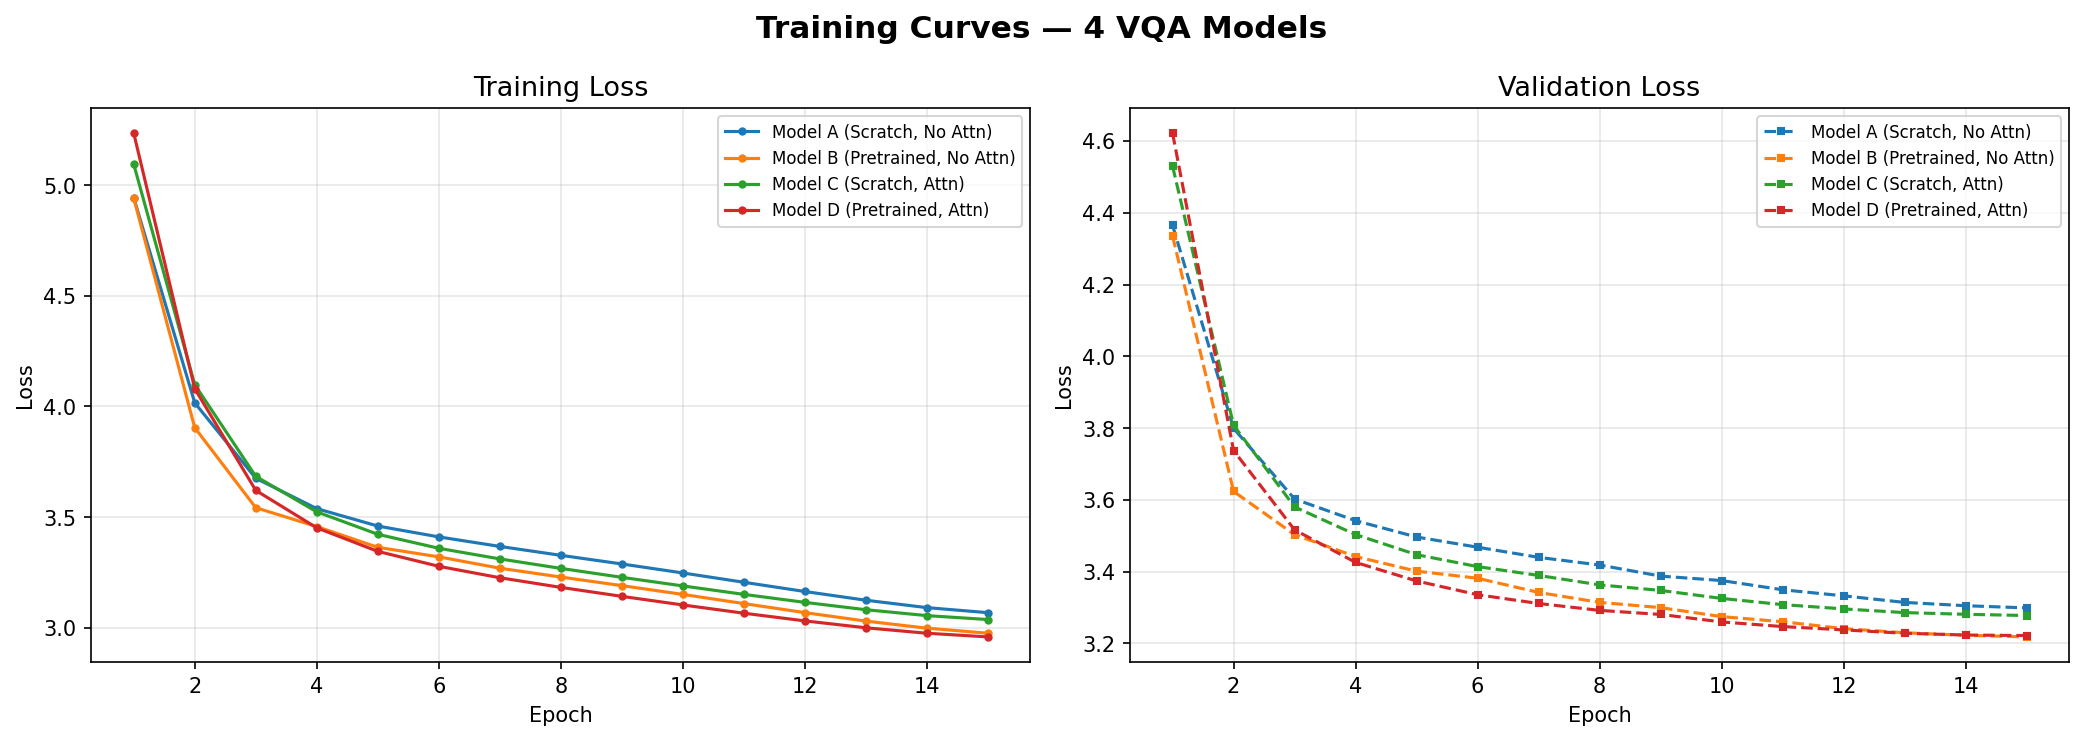

In [ ]:
# ── Generate training curves (saved to file) ─────────────────────────────────
!python src/plot_curves.py --output checkpoints/training_curves.png

# Display the saved plot
import os
from IPython.display import Image as IPImage, display
if os.path.exists("checkpoints/training_curves.png"):
    display(IPImage("checkpoints/training_curves.png", width=900))
else:
    print("⚠ Plot not generated — train at least one model first")

/tmp/ipykernel_4756/2241436779.py:48: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=8, loc='best')


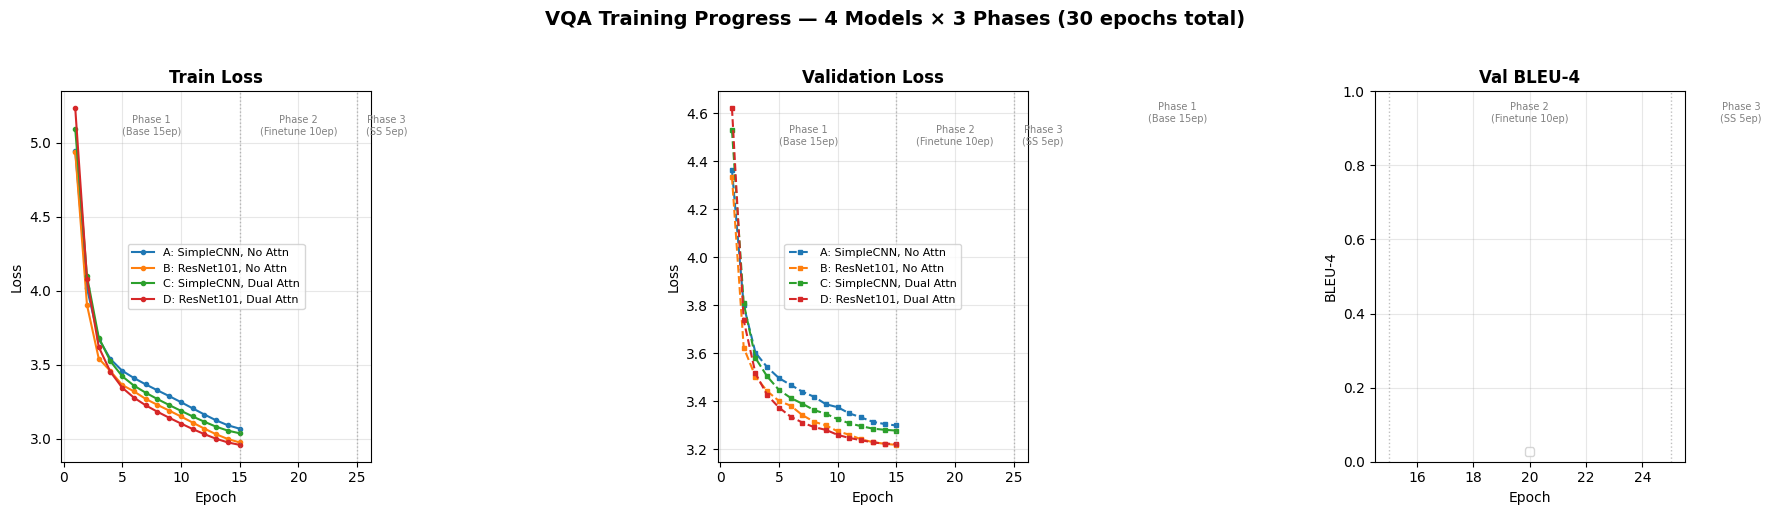

In [ ]:
# ── Inline Training Curves (4 models, 3 phases, annotated) ───────────────────
%matplotlib inline
import json, os
import matplotlib.pyplot as plt
import numpy as np

MODEL_COLORS = {'A': '#1f77b4', 'B': '#ff7f0e', 'C': '#2ca02c', 'D': '#d62728'}
MODEL_LABELS = {
    'A': 'A: SimpleCNN, No Attn',
    'B': 'B: ResNet101, No Attn',
    'C': 'C: SimpleCNN, Dual Attn',
    'D': 'D: ResNet101, Dual Attn',
}
PHASE_BOUNDARIES = [15, 25]  # epoch boundaries between phases (15+10+5=30)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
ax_train, ax_val, ax_bleu = axes

plotted_any = False
for m in 'ABCD':
    hp = f"checkpoints/history_model_{m.lower()}.json"
    if not os.path.exists(hp):
        continue
    h = json.load(open(hp))
    epochs = list(range(1, len(h['train_loss']) + 1))

    # Train loss
    ax_train.plot(epochs, h['train_loss'], color=MODEL_COLORS[m],
                  label=MODEL_LABELS[m], marker='o', ms=3, lw=1.5)
    # Val loss
    ax_val.plot(epochs, h['val_loss'], color=MODEL_COLORS[m],
                label=MODEL_LABELS[m], marker='s', ms=3, ls='--', lw=1.5)

    # BLEU-4 curve (if available in history)
    if 'val_bleu4' in h and h['val_bleu4']:
        ax_bleu.plot(epochs[:len(h['val_bleu4'])], h['val_bleu4'],
                     color=MODEL_COLORS[m], label=MODEL_LABELS[m],
                     marker='^', ms=3, lw=1.5)

    plotted_any = True

if plotted_any:
    for ax in [ax_train, ax_val, ax_bleu]:
        # Phase boundary lines
        for pe in PHASE_BOUNDARIES:
            ax.axvline(pe, color='gray', ls=':', alpha=0.5, lw=1)
        ax.set_xlabel('Epoch', fontsize=10)
        ax.legend(fontsize=8, loc='best')
        ax.grid(alpha=0.3)

    ax_train.set_ylabel('Loss'); ax_train.set_title('Train Loss', fontsize=12, fontweight='bold')
    ax_val.set_ylabel('Loss');   ax_val.set_title('Validation Loss', fontsize=12, fontweight='bold')
    ax_bleu.set_ylabel('BLEU-4'); ax_bleu.set_title('Val BLEU-4', fontsize=12, fontweight='bold')

    # Phase annotations
    for ax in [ax_train, ax_val, ax_bleu]:
        ymax = ax.get_ylim()[1]
        ax.text(7.5,  ymax*0.97, 'Phase 1\n(Base 15ep)', ha='center', fontsize=7, color='gray', va='top')
        ax.text(20,   ymax*0.97, 'Phase 2\n(Finetune 10ep)', ha='center', fontsize=7, color='gray', va='top')
        ax.text(27.5, ymax*0.97, 'Phase 3\n(SS 5ep)', ha='center', fontsize=7, color='gray', va='top')

    fig.suptitle('VQA Training Progress — 4 Models × 3 Phases (30 epochs total)', fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig("checkpoints/training_curves_inline.png", dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("⚠ No history files found — train at least one model first")

## 8. Qualitative Analysis — Sample Predictions

So sánh predictions của 4 models side-by-side trên validation samples.  
Hỗ trợ cả **Greedy** và **Beam Search** decode.

In [ ]:
# ── Load validation samples + models for qualitative analysis ─────────────────
import sys, os, json, torch, random
from PIL import Image
from torchvision import transforms
import matplotlib.pyplot as plt

sys.path.insert(0, 'src') if 'src' not in sys.path else None
from vocab import Vocabulary
from inference import load_model_from_checkpoint, greedy_decode, greedy_decode_with_attention, beam_search_decode

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Load vocab
vocab_q = Vocabulary(); vocab_q.load('data/processed/vocab_questions.json')
vocab_a = Vocabulary(); vocab_a.load('data/processed/vocab_answers.json')

# Load validation annotations
val_anns = json.load(open('data/raw/vqa_e_json/VQA-E_val_set.json'))
val_img_dir = 'data/raw/images/val2014'

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Select random samples
random.seed(42)
samples = random.sample(val_anns, 8)

# Load trained models (only if checkpoint exists)
loaded_models = {}
for m in 'ABCD':
    ckpt = f'checkpoints/model_{m.lower()}_best.pth'
    if os.path.exists(ckpt):
        model = load_model_from_checkpoint(
            m, ckpt, len(vocab_q), len(vocab_a), device=DEVICE
        )
        loaded_models[m] = model
        print(f"  ✓ Loaded Model {m} from {ckpt}")
    else:
        print(f"  ✗ Model {m}: {ckpt} not found")

print(f"\n  {len(loaded_models)} models loaded: {list(loaded_models.keys())}")

RuntimeError: Error(s) in loading state_dict for VQAModelA:
	Missing key(s) in state_dict: "i_encoder.features.0.0.weight", "i_encoder.features.0.0.bias", "i_encoder.features.0.1.weight", "i_encoder.features.0.1.bias", "i_encoder.features.0.1.running_mean", "i_encoder.features.0.1.running_var", "i_encoder.features.1.0.weight", "i_encoder.features.1.0.bias", "i_encoder.features.1.1.weight", "i_encoder.features.1.1.bias", "i_encoder.features.1.1.running_mean", "i_encoder.features.1.1.running_var", "i_encoder.features.2.0.weight", "i_encoder.features.2.0.bias", "i_encoder.features.2.1.weight", "i_encoder.features.2.1.bias", "i_encoder.features.2.1.running_mean", "i_encoder.features.2.1.running_var", "i_encoder.features.3.0.weight", "i_encoder.features.3.0.bias", "i_encoder.features.3.1.weight", "i_encoder.features.3.1.bias", "i_encoder.features.3.1.running_mean", "i_encoder.features.3.1.running_var", "i_encoder.features.4.0.weight", "i_encoder.features.4.0.bias", "i_encoder.features.4.1.w

In [ ]:
# ── Greedy vs Beam Search comparison ──────────────────────────────────────────
# So sánh output giữa greedy decode và beam search cho best model
%matplotlib inline
from inference import beam_search_decode_with_attention

if not loaded_models:
    print("⚠ No models loaded — skip")
else:
    # Pick best available model (prefer D > C > B > A)
    best_m = next((m for m in 'DCBA' if m in loaded_models), None)
    best_model = loaded_models[best_m]
    has_attn = best_m in ('C', 'D')

    # Select correct beam search function based on model type
    beam_fn = beam_search_decode_with_attention if has_attn else beam_search_decode

    print(f"Comparing Greedy vs Beam Search for Model {best_m}:\n")
    for i, ann in enumerate(samples[:5]):
        img_id = ann['img_id']
        q_text = ann['question']
        gt_ans = ann.get('multiple_choice_answer', '')
        gt_exp = ann.get('explanation', [''])[0] if ann.get('explanation') else ''
        gt_full = f"{gt_ans} because {gt_exp}" if gt_exp else gt_ans

        img_path = os.path.join(val_img_dir, f"COCO_val2014_{img_id:012d}.jpg")
        if not os.path.exists(img_path):
            continue

        img_pil    = Image.open(img_path).convert("RGB")
        img_tensor = transform(img_pil)
        q_tensor   = torch.tensor(vocab_q.numericalize(q_text), dtype=torch.long)

        # Greedy
        if has_attn:
            greedy_pred = greedy_decode_with_attention(best_model, img_tensor, q_tensor, vocab_a, device=DEVICE)
        else:
            greedy_pred = greedy_decode(best_model, img_tensor, q_tensor, vocab_a, device=DEVICE)

        # Beam search (width=5) — use correct function for attention models
        beam_pred = beam_fn(best_model, img_tensor, q_tensor, vocab_a,
                            device=DEVICE, beam_width=5, no_repeat_ngram_size=3)

        print(f"  [{i+1}] Q: {q_text}")
        print(f"      GT:    {gt_full}")
        print(f"      Greedy: {greedy_pred}")
        print(f"      Beam-5: {beam_pred}")
        print()

In [ ]:
# ── Visual predictions — Image + Question + All Models' Answers ───────────────
%matplotlib inline

if not loaded_models:
    print("⚠ No models loaded — skip")
else:
    n_show = min(5, len(samples))

    for idx in range(n_show):
        ann    = samples[idx]
        img_id = ann['img_id']
        q_text = ann['question']
        gt_ans = ann.get('multiple_choice_answer', '')
        gt_exp = ann.get('explanation', [''])[0] if ann.get('explanation') else ''
        gt_full = f"{gt_ans} because {gt_exp}" if gt_exp else gt_ans

        img_path = os.path.join(val_img_dir, f"COCO_val2014_{img_id:012d}.jpg")
        if not os.path.exists(img_path):
            print(f"⚠ Image not found: {img_path}")
            continue

        img_pil    = Image.open(img_path).convert("RGB")
        img_tensor = transform(img_pil)
        q_tensor   = torch.tensor(vocab_q.numericalize(q_text), dtype=torch.long)

        # Get predictions from all loaded models
        preds = {}
        for m, model in loaded_models.items():
            with torch.no_grad():
                if m in ('C', 'D'):
                    pred = greedy_decode_with_attention(model, img_tensor, q_tensor, vocab_a, device=DEVICE)
                else:
                    pred = greedy_decode(model, img_tensor, q_tensor, vocab_a, device=DEVICE)
            preds[m] = pred

        # Display image + predictions
        fig, ax = plt.subplots(1, 1, figsize=(5, 4))
        ax.imshow(img_pil)
        ax.axis('off')
        ax.set_title(f"Q: {q_text}", fontsize=9, wrap=True, pad=10)
        plt.tight_layout()
        plt.show()

        print(f"  {'Ground Truth':12s}: {gt_full}")
        for m, pred in sorted(preds.items()):
            marker = '★' if m in ('C', 'D') else ' '
            print(f"  {'Model ' + m:12s}: {pred} {marker}")
        print("─" * 70)

## 9. Attention Visualization (Model C/D)

Visualize vùng ảnh mà model "nhìn vào" khi sinh từng token.  
Model C/D có **49 spatial regions** (7×7 grid) — mỗi time step có một attention map.  
Dùng `visualize.py` hoặc inline function bên dưới.

In [ ]:

# Pick attention model (D preferred, fallback to C)
attn_model_type = 'D' if 'D' in loaded_models else ('C' if 'C' in loaded_models else None)

if attn_model_type is None:
    print("⚠ Model C/D chưa được train — hãy train trước.")
else:
    # Visualize attention for 3 samples
    for i, ann in enumerate(samples[:3]):
        img_id = ann['img_id']
        q_text = ann['question']
        img_path = f"data/raw/images/val2014/COCO_val2014_{img_id:012d}.jpg"
        ckpt = f"checkpoints/model_{attn_model_type.lower()}_best.pth"
        out_path = f"checkpoints/attention_viz_{i}.png"

        if not os.path.exists(img_path) or not os.path.exists(ckpt):
            print(f"⚠ Missing: {img_path} or {ckpt}")
            continue

        !python src/visualize.py \
            --model_type {attn_model_type} \
            --checkpoint {ckpt} \
            --image_path "{img_path}" \
            --question "{q_text}" \
            --output {out_path}

        if os.path.exists(out_path):
            from IPython.display import Image as IPImage, display
            print(f"\n  Sample {i+1}: Q = {q_text}")
            display(IPImage(out_path, width=800))
            print()

In [ ]:
# ── Interactive Attention Visualization Function ──────────────────────────────
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
from PIL import Image

def visualize_attention_inline(model, img_path, question, vocab_q, vocab_a, device, max_len=30):
    """
    Visualize attention weights for each generated token overlaid on the image.
    Works with Model C and D (spatial attention models).
    """
    from inference import greedy_decode_with_attention
    from visualize import decode_with_attention_steps

    img_pil = Image.open(img_path).convert("RGB")
    img_tensor = transform(img_pil)
    q_tensor = torch.tensor(vocab_q.numericalize(question), dtype=torch.long)

    # Get attention weights for each step
    try:
        words, attn_weights = decode_with_attention_steps(
            model, img_tensor, q_tensor, vocab_a, device=device, max_len=max_len
        )
    except Exception as e:
        print(f"Error: {e}")
        return

    n_words = len(words)
    if n_words == 0:
        print("No words generated")
        return

    # Display: original image + attention per word (max 8 words)
    n_show = min(n_words, 8)
    fig, axes = plt.subplots(1, n_show + 1, figsize=(3 * (n_show + 1), 3))

    # Original image
    axes[0].imshow(img_pil)
    axes[0].set_title("Original", fontsize=8)
    axes[0].axis('off')

    img_np = np.array(img_pil.resize((224, 224)))

    for i in range(n_show):
        ax = axes[i + 1]
        # Reshape attention to 7×7 grid
        attn = attn_weights[i].reshape(7, 7)
        attn_resized = np.array(Image.fromarray(attn).resize((224, 224), Image.BILINEAR))
        attn_resized = (attn_resized - attn_resized.min()) / (attn_resized.max() - attn_resized.min() + 1e-8)

        ax.imshow(img_np, alpha=0.6)
        ax.imshow(attn_resized, cmap='jet', alpha=0.4)
        ax.set_title(words[i], fontsize=9, fontweight='bold')
        ax.axis('off')

    fig.suptitle(f"Q: {question}", fontsize=10, y=1.05)
    plt.tight_layout()
    plt.show()
    print(f"  Full prediction: {' '.join(words)}")

# Example usage (only if attention model is loaded)
if attn_model_type and attn_model_type in loaded_models:
    print(f"Running interactive visualization with Model {attn_model_type}...\n")
    for ann in samples[:2]:
        img_id = ann['img_id']
        img_path = f"data/raw/images/val2014/COCO_val2014_{img_id:012d}.jpg"
        if os.path.exists(img_path):
            visualize_attention_inline(
                loaded_models[attn_model_type], img_path, ann['question'],
                vocab_q, vocab_a, DEVICE
            )
            print()
else:
    print("⚠ No attention model loaded — skip interactive visualization")

## 10. Training Progress & Resume

Nếu training bị ngắt giữa chừng, dùng `--resume` để tiếp tục từ checkpoint cuối.  
File `checkpoints/model_X_resume.pth` được overwrite sau mỗi epoch.

```bash
# Resume Model A Phase 1 (ví dụ bị dừng ở epoch 6/10)
python src/train.py --model A --epochs 10 --lr 1e-3 \
    --resume checkpoints/model_a_resume.pth \
    --batch_size 64 --accum_steps 2 --augment --glove --num_workers 6
```

> **Note:** `--epochs 10` là tổng số epochs tính từ đầu. Nếu đã chạy 6 epochs,  
> sẽ tiếp tục từ epoch 7 cho đến epoch 10 (4 epochs còn lại).

In [ ]:
# ── Kiểm tra trạng thái training hiện tại ────────────────────────────────────
import json, os

print("╔══════════════════════════════════════════════════════════════════╗")
print("║                     TRAINING PROGRESS                          ║")
print("╠══════════════════════════════════════════════════════════════════╣")
print(f"║ {'Model':<7} {'Epochs':>7} {'Phase':>8} {'Best Val':>10} {'Last Val':>10} {'Ckpt':>5} {'Best':>5} ║")
print("╠══════════════════════════════════════════════════════════════════╣")

for m in 'ABCD':
    history_path = f"checkpoints/history_model_{m.lower()}.json"
    resume_path  = f"checkpoints/model_{m.lower()}_resume.pth"
    best_path    = f"checkpoints/model_{m.lower()}_best.pth"

    if os.path.exists(history_path):
        h = json.load(open(history_path))
        n_epochs = len(h['train_loss'])
        best_val = min(h['val_loss']) if h['val_loss'] else float('inf')
        last_val = h['val_loss'][-1] if h['val_loss'] else float('inf')
        phase = 'Phase 1' if n_epochs <= 15 else ('Phase 2' if n_epochs <= 25 else 'Phase 3')
        has_ckpt = '✓' if os.path.exists(resume_path) else '✗'
        has_best = '✓' if os.path.exists(best_path) else '✗'
        print(f"║ {m:<7} {n_epochs:>7} {phase:>8} {best_val:>10.4f} {last_val:>10.4f} {has_ckpt:>5} {has_best:>5} ║")
    else:
        print(f"║ {m:<7} {'—':>7} {'—':>8} {'—':>10} {'—':>10} {'—':>5} {'—':>5} ║")

print("╚══════════════════════════════════════════════════════════════════╝")
print("\nLegend: Ckpt=resume checkpoint | Best=best model checkpoint")
print(f"Total training plan: Phase 1 (15ep) + Phase 2 (10ep) + Phase 3 (5ep) = 30 epochs")

## 11. Results Summary

Tổng hợp kết quả cuối cùng — chạy cell bên dưới sau khi hoàn thành cả 3 phases.

In [ ]:
# ── Final Results Summary ────────────────────────────────────────────────────
import json, os, subprocess

print("=" * 70)
print("  FINAL RESULTS SUMMARY — VQA Generative (VQA-E Dataset)")
print("=" * 70)
print()

# Check training completion
all_complete = True
for m in 'ABCD':
    hp = f"checkpoints/history_model_{m.lower()}.json"
    if os.path.exists(hp):
        h = json.load(open(hp))
        n = len(h['train_loss'])
        status = f"{n} epochs ({'✅ Complete' if n >= 30 else '⚠ Incomplete'})"
    else:
        status = "❌ Not trained"
        all_complete = False
    print(f"  Model {m}: {status}")

print()

# Run final comparison if all models trained
if all_complete:
    print("─" * 70)
    print("  Running final comparison (greedy, 2000 samples)...")
    print("─" * 70)
    !python src/compare.py --epoch 30 --num_samples 2000
    print()
    print("─" * 70)
    print("  Running final comparison (beam=5, 2000 samples)...")
    print("─" * 70)
    !python src/compare.py --epoch 30 --beam_width 5 --no_repeat_ngram 3 --num_samples 2000
else:
    print("  ⚠ Not all models completed 30 epochs. Complete training first.")

print()
print("=" * 70)
print("  Key Findings:")
print("  • Model D (ResNet101 + Dual Attention) expected to perform best")
print("  • Beam Search typically +1-2 BLEU-4 over Greedy")
print("  • Phase 2 (fine-tuning) gives biggest jump for B/D")
print("  • Phase 3 (scheduled sampling) reduces exposure bias")
print("=" * 70)

---

## Appendix

### A. Hyperparameter Summary (v3 Optimized)

| Hyperparameter | Value | Notes |
|---|---|---|
| Image size | 224×224 | Standard for CNN |
| Embedding dim | 300→512 | GloVe 300d + projection |
| Hidden dim | 1024 | LSTM + decoder |
| CNN features | 512 (A/C) · 2048 (B/D) | Projected to 1024 |
| Spatial regions | 49 (7×7) | C/D only |
| Attention | Bahdanau Dual | Image + Question attention |
| Dropout | 0.3 | embedding + LSTM inter-layer |
| Label smoothing | 0.1 | CrossEntropyLoss |
| Weight decay | **1e-4** | AdamW (tăng từ 1e-5) |
| Grad clip | **5.0** | Tăng từ 1.0 |
| LR warmup | 3 epochs | Phase 1 only |
| LR schedule | **CosineAnnealing** | Decay to LR×0.01 |
| Scheduled sampling k | 10 | ε = k/(k+exp(epoch/k)) |
| Max answer length | 30 tokens | Decode limit |
| Beam width | 5 | For beam search |
| N-gram blocking | 3-gram | Avoid repetition |
| Coverage loss | **α·log(cov+1)** | Proper re-attention penalty |
| Phase 1 | **15 epochs** | Base training |
| Phase 2 | **10 epochs** | Finetune + Coverage |
| Phase 3 | **5 epochs** | Scheduled Sampling |
| Total | **30 epochs** | 3 phases |

### B. VRAM Profile (RTX 3060 12GB, BF16)

| Model | Frozen BS | VRAM | Unfreeze BS | VRAM |
|-------|-----------|------|-------------|------|
| A | 128 | 5.9 GB | N/A | N/A |
| B | 128 | 1.1 GB | 96 | 3.9 GB |
| C | 96 | 5.9 GB | N/A | N/A |
| D | 128 | 2.4 GB | 96 | 5.3 GB |

### C. CLI Reference

```bash
# === Training ===
python src/train.py --model A --epochs 15 --lr 1e-3 \
    --batch_size 128 --augment --glove \
    --weight_decay 1e-4 --dropout 0.3 --grad_clip 5.0 \
    --num_workers 8 --early_stopping 10

# === Fine-tuning (Phase 2) ===
python src/train.py --model B --epochs 10 --lr 5e-4 \
    --finetune_cnn --cnn_lr_factor 0.1 \
    --resume checkpoints/model_b_resume.pth [common_args]

# === Scheduled Sampling (Phase 3) ===
python src/train.py --model C --epochs 5 --lr 1e-4 \
    --scheduled_sampling --coverage --ss_k 10 \
    --resume checkpoints/model_c_resume.pth [common_args]

# === Evaluation ===
python src/evaluate.py --model_type D --checkpoint checkpoints/model_d_best.pth
python src/evaluate.py --model_type D --checkpoint checkpoints/model_d_best.pth \
    --beam_width 5 --no_repeat_ngram 3 --num_samples 2000

# === Comparison ===
python src/compare.py --epoch 30 --num_samples 2000
python src/compare.py --epoch 30 --beam_width 3 --no_repeat_ngram 3

# === Visualization ===
python src/visualize.py --model_type D --checkpoint checkpoints/model_d_best.pth \
    --image_path "path/to/image.jpg" --question "What color is the cat?"

# === Utilities ===
python src/plot_curves.py --output checkpoints/training_curves.png
python src/scripts/1_build_vocab.py    # Rebuild vocabulary
watch -n 1 nvidia-smi                  # Monitor GPU in real-time
```

### D. Expected Results (Reference)

| Model | BLEU-4 (greedy) | BLEU-4 (beam) | METEOR | Notes |
|-------|:---:|:---:|:---:|-------|
| A | 0.05–0.10 | 0.06–0.11 | 0.10–0.18 | Baseline scratch CNN |
| B | 0.07–0.12 | 0.08–0.14 | 0.12–0.20 | Pretrained ResNet101 |
| C | 0.06–0.11 | 0.07–0.13 | 0.11–0.19 | Attention helps long answers |
| D | 0.08–0.15 | 0.10–0.17 | 0.13–0.22 | Best expected |

> Kết quả thực tế phụ thuộc vào random seed, augmentation, và early stopping.